<H2 style="text-align:center;"><strong>VARIABLES ONLINE</strong></H2>

**Objetivo General:**
Diseñar un modelo predictivo basado en técnicas de aprendizaje automático que, utilizando únicamente variables online disponibles en el proceso de fermentación, permita estimar la concentración de penicilina en tiempo real.

**Objetivos específicos:**
1. Identificar y seleccionar variables online relevantes del dataset IndPenSim que incidan en la producción de penicilina.
2. Estandarizar, limpiar y preparar los datos para su uso en modelos de predicción.
3. Entrenar y evaluar distintos modelos de regresión (Lasso, SVR, KNN, ANN, XGBoost) para estimar la concentración del producto.
4. Validar el desempeño de los modelos mediante métricas como el error cuadrático medio (RMSE), error absoluto medio (MAE) y coeficiente de determinación (R²).
5. Integrar un modelo final en un esquema de sensor blando (soft sensor), que simule su uso en una planta industrial.



## Importar Librerias

In [ ]:
# Manejo de datos
import pandas as pd
import numpy as np
# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
# Isolation Forest
from sklearn.ensemble import IsolationForest

from statsmodels.stats.outliers_influence import variance_inflation_factor
# BayesianOptimization
from bayes_opt import BayesianOptimization
# Pipeline
from sklearn.pipeline import Pipeline
# StandardScaler
from sklearn.preprocessing import StandardScaler
# Lasso
from sklearn.linear_model import Lasso
# mean_squared_error
from sklearn.metrics import mean_squared_error
# joblib
import joblib
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
import torch.nn as nn
from sklearn.base import BaseEstimator, RegressorMixin
# ANN
import torch
import torch.optim as optim
from sklearn.model_selection import train_test_split
# XGBRegressor
from xgboost import XGBRegressor
# PCA
from sklearn.decomposition import PCA
# KNeighborsRegressor
from sklearn.neighbors import KNeighborsRegressor
# BayesSearchCV
from skopt import BayesSearchCV
#VotingRegressor'
from sklearn.ensemble import VotingRegressor

from sklearn.base import BaseEstimator, RegressorMixin

#mpl
import matplotlib as mpl

# Ignorar advertencias (opcional, para limpieza visual)
import warnings
warnings.filterwarnings('ignore')

## Cargar y visualizar datos

En este paso cargamos los datos utilizando un directorio

In [2]:
data = pd.read_csv(r'C:/Users/Sandra Orozco\Dropbox/Maestria IAA/Reto Icesi INRAE/Mendeley_data/100_Batches_IndPenSim_V3.csv')
data

,Time (h),Aeration rate(Fg:L/h),Agitator RPM(RPM:RPM),Sugar feed rate(Fs:L/h),Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),...,210,209,208,207,206,205,204,203,202,201
0,0.2,30,100,8,0.0000,30.1180,9.8335,0.00010,0,0.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,0.4,30,100,8,0.0000,51.2210,18.1550,0.00010,0,0.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,0.6,30,100,8,0.0000,54.3020,9.5982,0.00010,0,0.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
3,0.8,30,100,8,0.0000,37.8160,4.3395,0.00010,0,0.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
4,1.0,30,100,8,0.5181,18.9080,1.1045,0.00010,0,0.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113930,229.2,65,100,80,0.0000,12.9000,33.5860,5.93590,250,0.9,...,816050.0,823390.0,830160.0,835530.0,839140.0,840570.0,840160.0,838580.0,NaN,NaN
113931,229.4,65,100,80,0.0000,10.0470,10.0760,98.83400,250,0.9,...,773520.0,780840.0,787470.0,792750.0,796220.0,797610.0,797270.0,796020.0,NaN,NaN
113932,229.6,65,100,80,0.0000,7.3609,69.3450,9.88340,250,0.9,...,788240.0,795550.0,802190.0,807420.0,810590.0,811660.0,811210.0,809960.0,NaN,NaN
113933,229.8,65,100,80,0.0000,6.2794,38.6100,0.98834,250,0.9,...,781180.0,788420.0,794950.0,800140.0,803610.0,804900.0,804490.0,803410.0,NaN,NaN


Aquí evidenciamos los tipos de variables que exiten en dataset y la forma general de los datos. En este caso encontramos variables float e int, así mismo observamos que hay columnas con valores nulos.

In [3]:
print("\nInformación del dataset:")
data.info()

print("\nForma general de los datos:")
display(data.describe().T)


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113935 entries, 0 to 113934
Columns: 2239 entries, Time (h) to 201
dtypes: float64(2225), int64(14)
memory usage: 1.9 GB

Forma general de los datos:


,count,mean,std,min,25%,50%,75%,max
Time (h),113935.0,1.147507e+02,66.990504,0.2,57.0,114.0,171.0,290.000
Aeration rate(Fg:L/h),113935.0,6.524636e+01,11.690215,20.0,60.0,65.0,75.0,75.000
Agitator RPM(RPM:RPM),113935.0,1.000000e+02,0.000000,100.0,100.0,100.0,100.0,100.000
Sugar feed rate(Fs:L/h),113935.0,7.666376e+01,25.680134,2.0,72.0,80.0,90.0,150.000
Acid flow rate(Fa:L/h),113935.0,7.320937e-02,0.552788,0.0,0.0,0.0,0.0,12.996
...,...,...,...,...,...,...,...,...
205,113935.0,1.441100e+06,659721.197945,0.0,862085.0,1448400.0,1994100.0,2936400.000
204,113935.0,1.441329e+06,660341.546970,0.0,861785.0,1448600.0,1994900.0,2938300.000
203,113935.0,1.440539e+06,660944.062181,0.0,860445.0,1447800.0,1994600.0,2939400.000
202,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Se genera un archivo .txt para conocer y explorar todas las columnas del dataset

In [4]:
with open('columnas.txt', 'w') as file:
    for col in data.columns:
        file.write(col + '\n')

Identificamos los valores nulos por cada columna

In [6]:
print("\nValores nulos en cada columna:")
print(data.isnull().sum())  


Valores nulos en cada columna:
Time (h)                        0
Aeration rate(Fg:L/h)           0
Agitator RPM(RPM:RPM)           0
Sugar feed rate(Fs:L/h)         0
Acid flow rate(Fa:L/h)          0
                            ...  
205                             0
204                             0
203                             0
202                        113935
201                        113935
Length: 2239, dtype: int64


### Análisis de Correlación 

Para hacer un Análisis de Correlación primero debemos filtrar las variables de proceso (variables online) y excluir los espectros Raman.

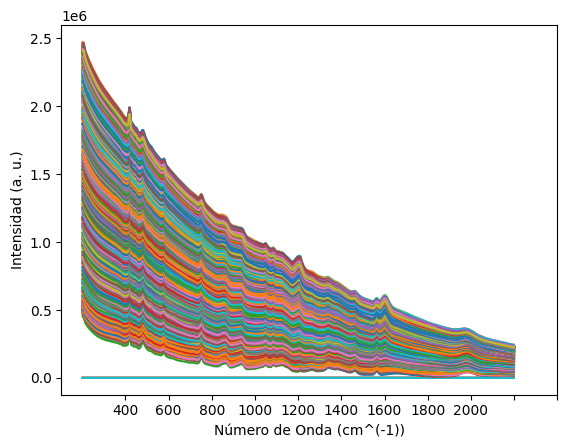

In [7]:
variable_raman_data = np.split(data, [data.columns.get_loc("2400")], axis=1) # dividimos nuestros datos en variables y espectros. 
variable_data = variable_raman_data[0] # asignación a la variable los datos anteriores a 2400 (columna 0 a la 39)

# Se encontró que hay dos columnas con nombres cruzados por lo tanto se intercambian nombres de las columnas
variable_data = variable_data.rename(columns={'2-PAT control(PAT_ref:PAT ref)': 'Batch reference(Batch_ref:Batch ref)','Batch reference(Batch_ref:Batch ref)':'2-PAT control(PAT_ref:PAT ref)'})

raman_spectra = variable_raman_data[1] # Separación de los espectros

# Gráfica espectros Raman

Intensity = raman_spectra.iloc[0:1129, 201:2600]
Temp = Intensity.transpose()

Temp_inverted = Temp.iloc[::-1]

Temp_inverted.index

x_values = np.array(Temp_inverted.index)

for column in Temp:
    # Convertir la serie de Pandas a un array de NumPy
    y_values = np.array(Temp_inverted[column])

    plt.plot(x_values, y_values, label=column)

x_ticks = range(199, 2399, 200)
plt.xticks(x_ticks) 
plt.ylabel('Intensidad (a. u.)')
plt.xlabel('Número de Onda (cm^(-1))')

plt.show()

In [8]:
# variables disponibles
variables = variable_data.columns.tolist()  
print("\nVariables disponibles en el dataset:")
for var in variables:
    print(var)
# Guardar las variables disponibles en un archivo de texto
with open('variables_disponibles.txt', 'w') as file:
    for var in variables:
        file.write(var + '\n')


Variables disponibles en el dataset:
Time (h)
Aeration rate(Fg:L/h)
Agitator RPM(RPM:RPM)
Sugar feed rate(Fs:L/h)
Acid flow rate(Fa:L/h)
Base flow rate(Fb:L/h)
Heating/cooling water flow rate(Fc:L/h)
Heating water flow rate(Fh:L/h)
Water for injection/dilution(Fw:L/h)
Air head pressure(pressure:bar)
Dumped broth flow(Fremoved:L/h)
Substrate concentration(S:g/L)
Dissolved oxygen concentration(DO2:mg/L)
Penicillin concentration(P:g/L)
Vessel Volume(V:L)
Vessel Weight(Wt:Kg)
pH(pH:pH)
Temperature(T:K)
Generated heat(Q:kJ)
carbon dioxide percent in off-gas(CO2outgas:%)
PAA flow(Fpaa:PAA flow (L/h))
PAA concentration offline(PAA_offline:PAA (g L^{-1}))
Oil flow(Foil:L/hr)
NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))
Oxygen Uptake Rate(OUR:(g min^{-1}))
Oxygen in percent in off-gas(O2:O2  (%))
Offline Penicillin concentration(P_offline:P(g L^{-1}))
Offline Biomass concentratio(X_offline:X(g L^{-1}))
Carbon evolution rate(CER:g/h)
Ammonia shots(NH3_shots:kgs)
Viscosity(Viscosity_o

### Selección de Variables 

Teniendo en cuenta que vamos a trabajar por lotes procedemos a especificar variables seleccionada. Se seleccionaron variables online por su disponibilidad en tiempo real, relevancia en la dinámica del proceso (como pH, temperatura, oxígeno, agitación) y correlación con la producción de penicilina. Además, `Time` y `Batch ID` permiten analizar la evolución del proceso por lote.


1.  Time (h)
2.  Agitator RPM(RPM:RPM)
3.  Sugar feed rate(Fs:L/h)
4.  Dissolved oxygen concentration(DO2:mg/L)
5.  Penicillin concentration(P:g/L) --> VARIABLE OBJETIVO
6.  Vessel Volume(V:L)
7.  pH(pH:pH)
8.  Temperature(T:K)
9.  Carbon dioxide percent in off-gas(CO2outgas:%)
10. Oxygen in percent in off-gas(O2:O2  (%))
11. Batch ID



In [9]:
data_select = data[['Time (h)', 'Agitator RPM(RPM:RPM)', 'Sugar feed rate(Fs:L/h)', 'Dissolved oxygen concentration(DO2:mg/L)', 
                    'Penicillin concentration(P:g/L)', 'Vessel Volume(V:L)', 'pH(pH:pH)', 'Temperature(T:K)', 'carbon dioxide percent in off-gas(CO2outgas:%)', 
                    'Oxygen in percent in off-gas(O2:O2  (%))', '2-PAT control(PAT_ref:PAT ref)']]                       
                    
# Renombramos la variable 2-PAT control(PAT_ref:PAT ref)': 'Batch'
data_select = data_select.rename(columns={'2-PAT control(PAT_ref:PAT ref)': 'Batch'})
data_select.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
Time (h),113935.0,114.750656,66.990504,2.000000e-01,57.00000,114.00000,171.00000,290.00000
Agitator RPM(RPM:RPM),113935.0,100.000000,0.000000,1.000000e+02,100.00000,100.00000,100.00000,100.00000
Sugar feed rate(Fs:L/h),113935.0,76.663764,25.680134,2.000000e+00,72.00000,80.00000,90.00000,150.00000
Dissolved oxygen concentration(DO2:mg/L),113935.0,12.569647,1.498680,1.000000e+00,11.63900,12.63600,13.61400,16.50800
Penicillin concentration(P:g/L),113935.0,14.333946,9.932453,3.694700e-26,5.53125,14.38000,22.68750,36.18300
Vessel Volume(V:L),113935.0,73312.865441,8599.642160,5.654900e+04,65885.50000,75770.00000,79892.00000,95716.00000
pH(pH:pH),113935.0,6.496565,0.065676,5.395700e+00,6.49320,6.50090,6.50860,6.76640
Temperature(T:K),113935.0,298.026489,0.197513,2.968400e+02,297.95000,297.99000,298.04000,302.18000
carbon dioxide percent in off-gas(CO2outgas:%),113935.0,1.444042,0.498955,7.542500e-02,1.22590,1.59630,1.75730,7.12140
Oxygen in percent in off-gas(O2:O2 (%)),113935.0,0.191458,0.004718,1.295000e-01,0.18886,0.19118,0.19366,0.22751


Identificamos los valores Nulos del Data seleccionado

In [10]:
# Calcular nulos por columna
valores_nulos = data_select.isnull().sum()

# Filtrar solo las columnas que tienen al menos un valor nulo
variables_con_nulos = valores_nulos[valores_nulos > 0]

# Mostrar resultados
print("Columnas con valores nulos:")
print(variables_con_nulos)

Columnas con valores nulos:
Series([], dtype: int64)


Definimos las Variables para el Análisis Exploratorio de Datos. Aqui no definimos: Time (h), Penicillin concentration(P:g/L)

In [12]:
variables = [
    'Agitator RPM(RPM:RPM)', 
    'Sugar feed rate(Fs:L/h)', 
    'Dissolved oxygen concentration(DO2:mg/L)', 
    'Vessel Volume(V:L)',
    'pH(pH:pH)',
    'Temperature(T:K)', 
    'carbon dioxide percent in off-gas(CO2outgas:%)', 
    'Oxygen in percent in off-gas(O2:O2  (%))'
]

Calculamos estadísticas descriptivas (media, mediana, desviación estándar, máximos y mínimos) para las variables clave del proceso. Además, se graficaron histogramas para observar la distribución de los datos y boxplots para identificar posibles valores atípicos.


In [13]:
# Filtrar datos relevantes
data_stats = data[variables]

# Calcular estadísticas descriptivas
estadisticas = data_stats.describe().T  # Transpuesta para mayor legibilidad
estadisticas['mediana'] = data_stats.median()
estadisticas = estadisticas[['mean', 'mediana', 'std', 'min', 'max']]

# Mostrar resumen
print("Estadísticas descriptivas:")
display(estadisticas)


Estadísticas descriptivas:


,mean,mediana,std,min,max
Agitator RPM(RPM:RPM),100.000000,100.00000,0.000000,100.000000,100.00000
Sugar feed rate(Fs:L/h),76.663764,80.00000,25.680134,2.000000,150.00000
Dissolved oxygen concentration(DO2:mg/L),12.569647,12.63600,1.498680,1.000000,16.50800
Vessel Volume(V:L),73312.865441,75770.00000,8599.642160,56549.000000,95716.00000
pH(pH:pH),6.496565,6.50090,0.065676,5.395700,6.76640
Temperature(T:K),298.026489,297.99000,0.197513,296.840000,302.18000
carbon dioxide percent in off-gas(CO2outgas:%),1.444042,1.59630,0.498955,0.075425,7.12140
Oxygen in percent in off-gas(O2:O2 (%)),0.191458,0.19118,0.004718,0.129500,0.22751


### Análisis Univariado

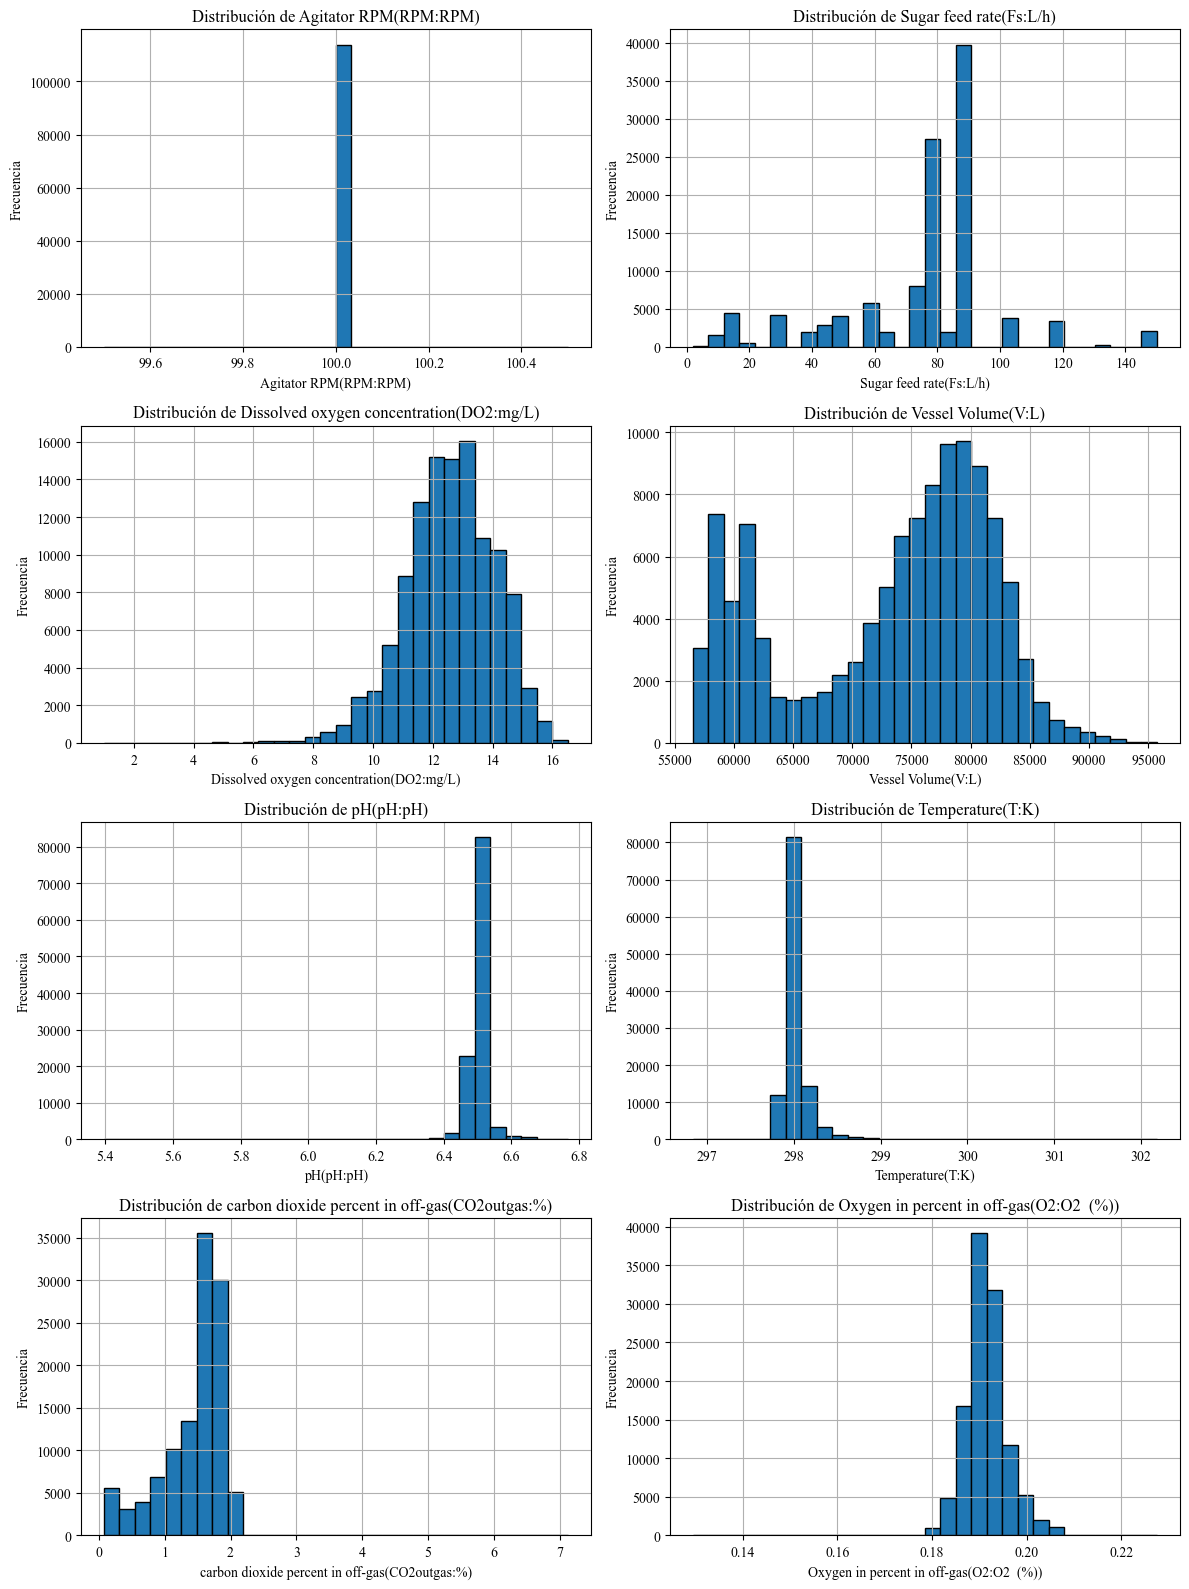

In [18]:
n = len(variables)
filas = (n + 1) // 2
fig, axes = plt.subplots(filas, 2, figsize=(12, 4 * filas))
axes = axes.flatten()
for i, var in enumerate(variables):
    data[var].hist(bins=30, edgecolor='black', ax=axes[i])
    axes[i].set_title(f"Distribución de {var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Frecuencia")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [19]:
print(data['Agitator RPM(RPM:RPM)'].unique())

[100]


### Análsis Bivariado

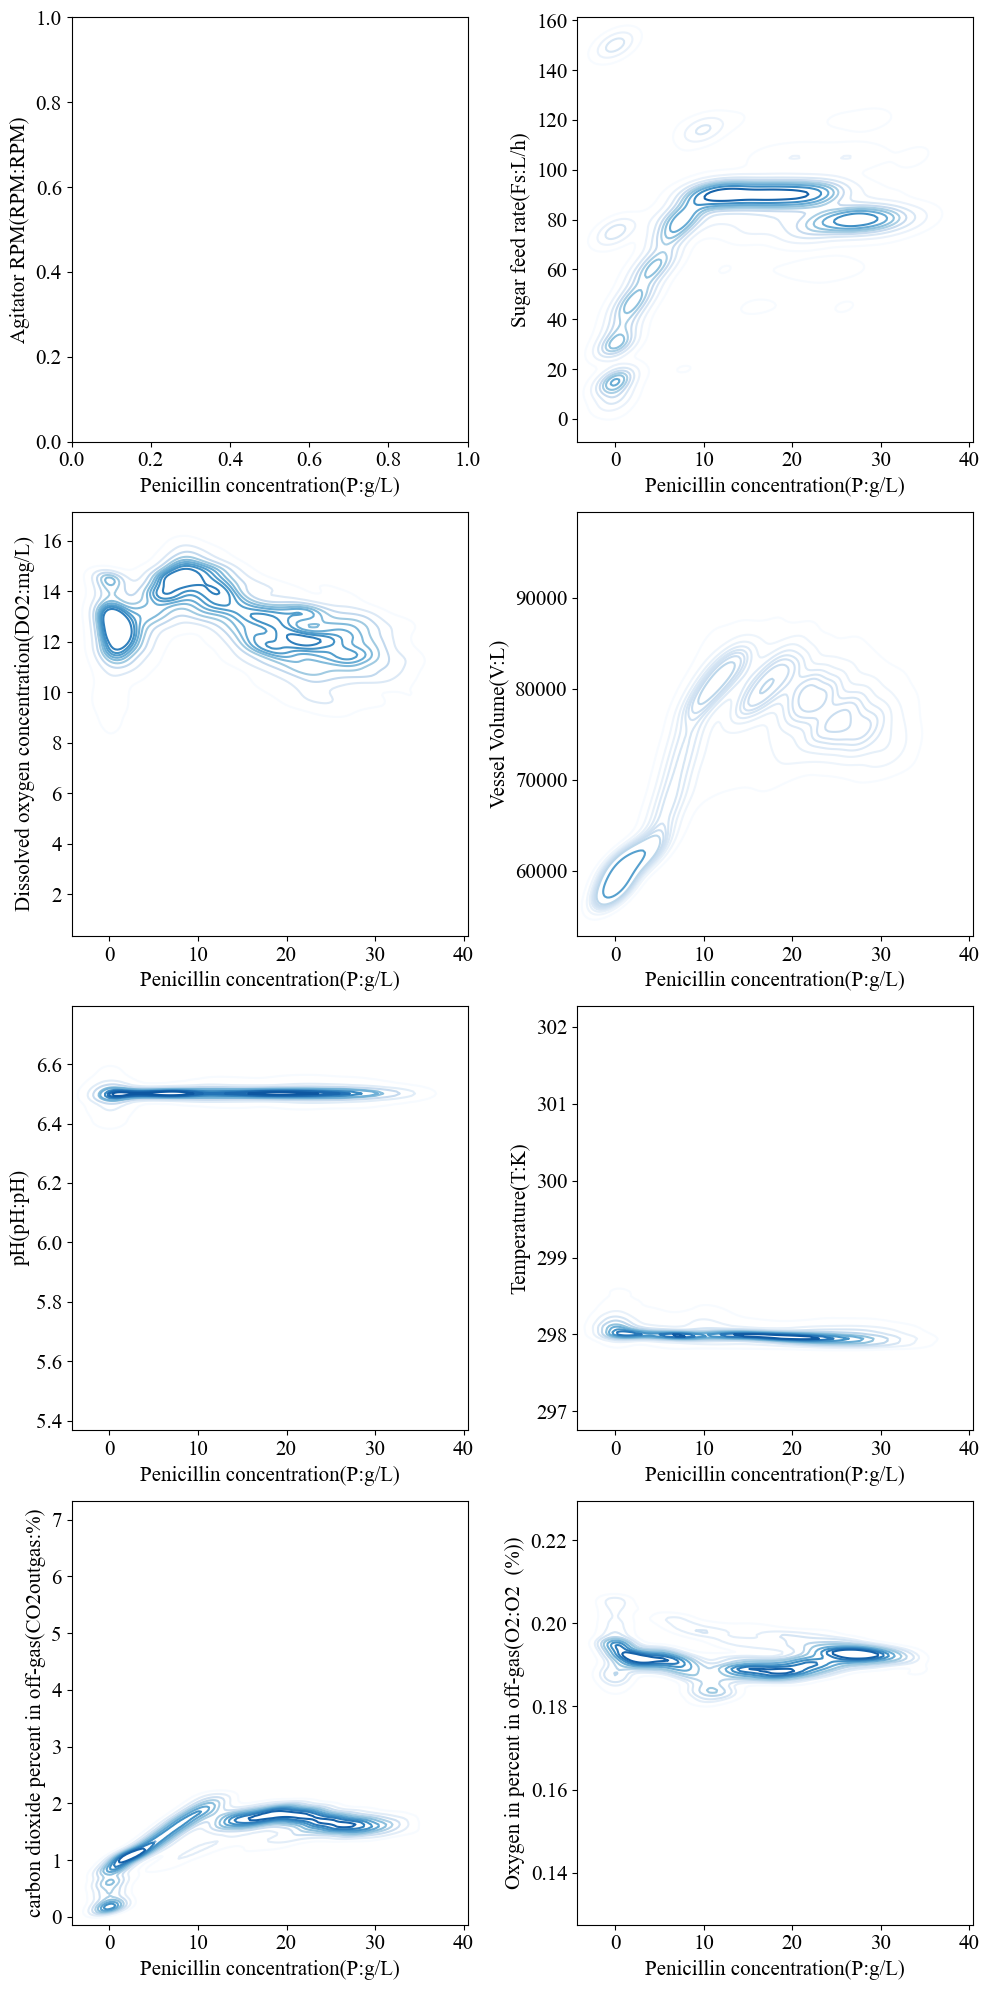

In [23]:
# Variable independiente
x_var = 'Penicillin concentration(P:g/L)'

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(10, 20))
fig.tight_layout(pad=5.0)

# Iterar sobre variables y crear gráficos bivariados
for i, var in enumerate(variables):  
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    
    # Diagrama de densidad
    sns.kdeplot(x=data_select[x_var], y=data_select[var], cmap='Blues', ax=ax)
    
    # Etiquetas
    ax.set_xlabel(x_var, fontsize=15)
    ax.set_ylabel(var, fontsize=15)
    ax.tick_params(axis='x', labelsize=15)
    ax.tick_params(axis='y', labelsize=15)

plt.tight_layout()
plt.show()


### Análisis Multivariado

Aquí se muestra la correlación entre las variables de proceso seleccionadas, incluida la concentración de penicilina, que es la variable objetivo. 

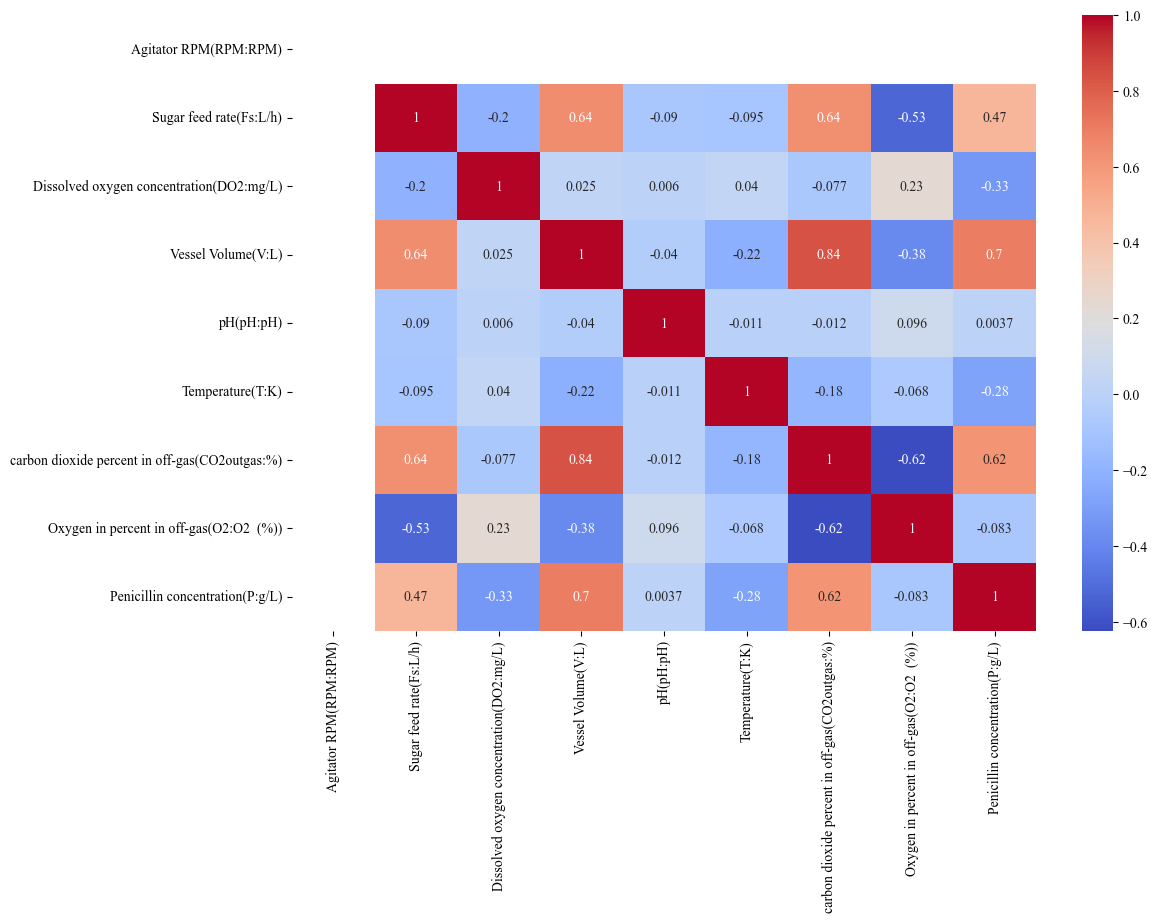

In [24]:
# Selección de variables
data_select1 = data[['Agitator RPM(RPM:RPM)', 
    'Sugar feed rate(Fs:L/h)', 
    'Dissolved oxygen concentration(DO2:mg/L)', 
    'Vessel Volume(V:L)',
    'pH(pH:pH)',
    'Temperature(T:K)', 
    'carbon dioxide percent in off-gas(CO2outgas:%)', 
    'Oxygen in percent in off-gas(O2:O2  (%))', 
    'Penicillin concentration(P:g/L)']]

# Correlación entre variables numéricas
plt.figure(figsize=(12, 8))
sns.heatmap(data_select1.corr(), annot=True, cmap='coolwarm')
plt.show()



In [27]:
# Calcular el VIF para cada variable
X = data_select1.dropna()  # Asegúrate de eliminar valores nulos antes
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

                                          feature           VIF
0                           Agitator RPM(RPM:RPM)  2.586136e+06
1                         Sugar feed rate(Fs:L/h)  2.120782e+00
2        Dissolved oxygen concentration(DO2:mg/L)  1.803388e+00
3                              Vessel Volume(V:L)  5.209875e+00
4                                       pH(pH:pH)  1.027925e+00
5                                Temperature(T:K)  1.115187e+00
6  carbon dioxide percent in off-gas(CO2outgas:%)  6.403930e+00
7        Oxygen in percent in off-gas(O2:O2  (%))  3.319619e+00
8                 Penicillin concentration(P:g/L)  3.951604e+00


La mayoria de las variables indican poca colinealidad excepto de: carbon dioxide percent in off-gas(CO2outgas:%) con 6.40  vessel volume(V:L) con 5.21.

### Particionamiento train y test 

In [38]:
# Se realiza el particionamiento en train y en test con la estratégia de control: Controlado por un enfoque basado en recetas.

id_grecipe_train = [21, 13, 26, 9, 29, 30, 11, 24, 3, 20, 7, 22, 17, 5, 6, 12, 
                    10, 19, 25, 27, 4, 1, 8]
id_grecipe_test = [2, 14, 15, 16, 18, 23, 28]

# Utilizar una comprensión de lista para obtener los grupos
recipe_train = [data_select.groupby('Batch').get_group(id) for id in id_grecipe_train]
recipe_test = [data_select.groupby('Batch').get_group(id) for id in id_grecipe_test]

# Combinar los grupos
grecipe_train = pd.concat(recipe_train)
grecipe_test = pd.concat(recipe_test)

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_grecipe = grecipe_train.drop(['Batch','Penicillin concentration(P:g/L)', 'Time (h)'], axis=1)
y_train_grecipe = grecipe_train["Penicillin concentration(P:g/L)"]
X_test_grecipe = grecipe_test.drop(['Batch','Penicillin concentration(P:g/L)', 'Time (h)'], axis=1)
y_test_grecipe = grecipe_test["Penicillin concentration(P:g/L)"]

### Modelo Lasso 

In [50]:
# Definir una función para entrenar y evaluar un modelo Lasso con más hiperparámetros
def lasso_cv(alpha, max_iter, tol, fit_intercept, normalize):
    fit_intercept = bool(round(fit_intercept))
    normalize = bool(round(normalize))
    
    model = Pipeline([
        ('scaler', StandardScaler(with_mean=normalize)),
        ('lasso', Lasso(alpha=alpha, max_iter=int(max_iter), tol=tol, fit_intercept=fit_intercept))
    ])
    model.fit(X_train_grecipe, y_train_grecipe)
    y_pred = model.predict(X_test_grecipe)
    return -mean_squared_error(y_test_grecipe, y_pred)

# Definir el espacio de búsqueda para la optimización bayesiana
pbounds = {
    'alpha': (0.001, 1),
    'max_iter': (100, 1000),
    'tol': (1e-5, 1e-1),
    'fit_intercept': (0, 1),  
    'normalize': (0, 1)       
}

# Optimización bayesiana para Lasso
lasso_optimizer = BayesianOptimization(f=lasso_cv, pbounds=pbounds, random_state=42, allow_duplicate_points=True)
lasso_optimizer.maximize(init_points=10, n_iter=30)

# Obtener el mejor conjunto de hiperparámetros para Lasso
best_params = lasso_optimizer.max['params']
best_alpha = best_params['alpha']
best_max_iter = int(best_params['max_iter'])
best_tol = best_params['tol']
best_fit_intercept = bool(round(best_params['fit_intercept']))
best_normalize = bool(round(best_params['normalize']))

# Entrenar el modelo Lasso con los mejores hiperparámetros
lasso_model_grecipe = Pipeline([
    ('scaler', StandardScaler(with_mean=best_normalize)),
    ('lasso', Lasso(alpha=best_alpha, max_iter=best_max_iter, tol=best_tol, fit_intercept=best_fit_intercept))
])
lasso_model_grecipe.fit(X_train_grecipe, y_train_grecipe)


|   iter    |  target   |   alpha   | fit_in... | max_iter  | normalize |    tol    |
-------------------------------------------------------------------------------------
| 1         | -25.44    | 0.3752    | 0.9507    | 758.8     | 0.5987    | 0.01561   |
| 2         | -235.8    | 0.1568    | 0.05808   | 879.6     | 0.6011    | 0.07081   |
| 3         | -23.96    | 0.02156   | 0.9699    | 849.2     | 0.2123    | 0.01819   |
| 4         | -38.9     | 0.1842    | 0.3042    | 572.3     | 0.4319    | 0.02913   |
| 5         | -43.21    | 0.6122    | 0.1395    | 362.9     | 0.3664    | 0.04561   |
| 6         | -245.3    | 0.7854    | 0.1997    | 562.8     | 0.5924    | 0.004655  |
| 7         | -242.3    | 0.6079    | 0.1705    | 158.5     | 0.9489    | 0.09656   |
| 8         | -246.3    | 0.8086    | 0.3046    | 187.9     | 0.6842    | 0.04402   |
| 9         | -235.2    | 0.1229    | 0.4952    | 130.9     | 0.9093    | 0.02589   |
| 10        | -242.8    | 0.6629    | 0.3117    | 568.

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 Lasso(alpha=np.float64(0.08621899631748546), max_iter=347,
                       tol=np.float64(0.07582827751874303)))])

In [51]:
print(f"Best alpha: {best_alpha}")
print(f"Best max_iter: {best_max_iter}")
print(f"Best tol: {best_tol}")
print(f"Best fit_intercept: {best_fit_intercept}")
print(f"Best normalize: {best_normalize}")

Best alpha: 0.08621899631748546
Best max_iter: 347
Best tol: 0.07582827751874303
Best fit_intercept: True
Best normalize: True


In [60]:
# Guardar el modelo entrenado
joblib.dump(lasso_model_grecipe, 'lasso_model_grecipe.pkl')

# Cargar el modelo entrenado
loaded_model_lasso_grecipe = joblib.load('lasso_model_grecipe.pkl')
loaded_model_lasso_grecipe

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 Lasso(alpha=np.float64(0.08621899631748546), max_iter=347,
                       tol=np.float64(0.07582827751874303)))])

In [65]:
# Predecir con el modelo entrenado
y_pred_lasso_grecipe = loaded_model_lasso_grecipe.predict(X_test_grecipe)

# Calcular las métricas
mse_lasso_grecipe = mean_squared_error(y_test_grecipe, y_pred_lasso_grecipe)
rmse_lasso_grecipe = np.sqrt(mse_lasso_grecipe)
mae_lasso_grecipe = mean_absolute_error(y_test_grecipe, y_pred_lasso_grecipe)
r2_lasso_grecipe = r2_score(y_test_grecipe, y_pred_lasso_grecipe)

# Imprimir las métricas
print(f"Mean Squared Error (MSE): {mse_lasso_grecipe:.5f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lasso_grecipe:.5f}")
print(f"Mean Absolute Error (MAE): {mae_lasso_grecipe:.5f}")
print(f"R-squared (R^2): {r2_lasso_grecipe:.5f}")

Mean Squared Error (MSE): 23.55212
Root Mean Squared Error (RMSE): 4.85305
Mean Absolute Error (MAE): 3.68425
R-squared (R^2): 0.78373


In [66]:
# Convertir las predicciones a un DataFrame de pandas
pred_lasso_grecipe = pd.DataFrame(y_pred_lasso_grecipe, columns=['pred_lasso_grecipe'])

# Guardar el DataFrame como un archivo CSV
pred_lasso_grecipe.to_csv('y_pred_lasso_grecipe.csv', index=False)

### Modelo Random Forest 

In [69]:
# Definir una función para entrenar y evaluar un modelo Random Forest
def rf_cv(n_estimators, max_depth, max_features, min_samples_split, min_samples_leaf, bootstrap):
    model = RandomForestRegressor(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        max_features=max_features,
        min_samples_split=int(min_samples_split),
        min_samples_leaf=int(min_samples_leaf),
        bootstrap=bootstrap > 0.5  # Convierte a booleano
    )
    model.fit(X_train_grecipe, y_train_grecipe)
    y_pred = model.predict(X_test_grecipe)
    return -mean_squared_error(y_test_grecipe, y_pred)

# Optimización bayesiana para Random Forest
pbounds = {
    'n_estimators': (10, 200),
    'max_depth': (1, 20),
    'max_features': (0.1, 1.0),  # Se asume un valor flotante entre 0.1 y 1.0
    'min_samples_split': (2, 20),
    'min_samples_leaf': (1, 20),
    'bootstrap': (0, 1)  # Se usará 0 para False y 1 para True
}

rf_optimizer = BayesianOptimization(f=rf_cv, pbounds=pbounds, random_state=42)
rf_optimizer.maximize(init_points=10, n_iter=30)

# Obtener los mejores valores de hiperparámetros para Random Forest
best_params = rf_optimizer.max['params']
best_n_estimators = int(best_params['n_estimators'])
best_max_depth = int(best_params['max_depth'])
best_max_features = best_params['max_features']
best_min_samples_split = int(best_params['min_samples_split'])
best_min_samples_leaf = int(best_params['min_samples_leaf'])
best_bootstrap = best_params['bootstrap'] > 0.5

# Entrenar el modelo Random Forest con los mejores valores de hiperparámetros
rf_model_grecipe = RandomForestRegressor(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    max_features=best_max_features,
    min_samples_split=best_min_samples_split,
    min_samples_leaf=best_min_samples_leaf,
    bootstrap=best_bootstrap
)
rf_model_grecipe.fit(X_train_grecipe, y_train_grecipe)

|   iter    |  target   | bootstrap | max_depth | max_fe... | min_sa... | min_sa... | n_esti... |
-------------------------------------------------------------------------------------------------
| 1         | -6.257    | 0.3745    | 19.06     | 0.7588    | 12.37     | 4.808     | 39.64     |
| 2         | -5.898    | 0.05808   | 17.46     | 0.641     | 14.45     | 2.371     | 194.3     |
| 3         | -13.04    | 0.8324    | 5.034     | 0.2636    | 4.485     | 7.476     | 109.7     |
| 4         | -6.918    | 0.4319    | 6.533     | 0.6507    | 3.65      | 7.259     | 79.61     |
| 5         | -5.501    | 0.4561    | 15.92     | 0.2797    | 10.77     | 12.66     | 18.83     |
| 6         | -22.11    | 0.6075    | 4.24      | 0.1585    | 19.03     | 19.38     | 163.6     |
| 7         | -25.43    | 0.3046    | 2.856     | 0.7158    | 9.363     | 4.197     | 104.1     |
| 8         | -5.653    | 0.03439   | 18.28     | 0.3329    | 13.59     | 7.611     | 108.8     |
| 9         | -11.0 

RandomForestRegressor(bootstrap=np.False_, max_depth=15,
                      max_features=np.float64(0.2797064039425238),
                      min_samples_leaf=10, min_samples_split=12,
                      n_estimators=18)

In [70]:
#print(f"Best params: {best_params}")
print(f"Best n estimators: {best_n_estimators}")
print(f"Best max depth: {best_max_depth}")
print(f"Best max features: {best_max_features}")
print(f"Best min samples split: {best_min_samples_split}")
print(f"Best min samples leaf: {best_min_samples_leaf}")
print(f"Best best_bootstrap: {best_bootstrap}")

Best n estimators: 18
Best max depth: 15
Best max features: 0.2797064039425238
Best min samples split: 12
Best min samples leaf: 10
Best best_bootstrap: False


In [71]:
# Guardar el modelo entrenado
joblib.dump(rf_model_grecipe, 'rf_model_grecipe.pkl')

# Cargar el modelo entrenado
loaded_model_rf_grecipe = joblib.load('rf_model_grecipe.pkl')
loaded_model_rf_grecipe

RandomForestRegressor(bootstrap=np.False_, max_depth=15,
                      max_features=np.float64(0.2797064039425238),
                      min_samples_leaf=10, min_samples_split=12,
                      n_estimators=18)

In [72]:
# Predecir con el modelo entrenado
y_pred_rf_grecipe = loaded_model_rf_grecipe.predict(X_test_grecipe)

# Calcular las métricas
mse_rf_grecipe = mean_squared_error(y_test_grecipe, y_pred_rf_grecipe)
rmse_rf_grecipe = np.sqrt(mse_rf_grecipe)
mae_rf_grecipe = mean_absolute_error(y_test_grecipe, y_pred_rf_grecipe)
r2_rf_grecipe = r2_score(y_test_grecipe, y_pred_rf_grecipe)

# Imprimir las métricas
print(f"Mean Squared Error (MSE): {mse_rf_grecipe:.5f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf_grecipe:.5f}")
print(f"Mean Absolute Error (MAE): {mae_rf_grecipe:.5f}")
print(f"R-squared (R^2): {r2_rf_grecipe:.5f}")

Mean Squared Error (MSE): 5.94040
Root Mean Squared Error (RMSE): 2.43729
Mean Absolute Error (MAE): 1.55443
R-squared (R^2): 0.94545


In [73]:
# Convertir las predicciones a un DataFrame de pandas
pred_rf_grecipe = pd.DataFrame(y_pred_rf_grecipe, columns=['pred_rf_grecipe'])

# Guardar el DataFrame como un archivo CSV
pred_rf_grecipe.to_csv('y_pred_rf_grecipe.csv', index=False)

### Modelo ANN 

|   iter    |  target   | activa... | batch_... | dropou... |  epochs   | hidden... | hidden... | hidden... |
-------------------------------------------------------------------------------------------------------------
Epoch 1/33, RMSE: 0.3800
Epoch 2/33, RMSE: 0.3494
Epoch 3/33, RMSE: 0.3356
Epoch 4/33, RMSE: 0.3219
Epoch 5/33, RMSE: 0.2973
Epoch 6/33, RMSE: 0.2899
Epoch 7/33, RMSE: 0.2746
Epoch 8/33, RMSE: 0.2726
Epoch 9/33, RMSE: 0.2835
Epoch 10/33, RMSE: 0.2660
Epoch 11/33, RMSE: 0.2815
Epoch 12/33, RMSE: 0.2894
Epoch 13/33, RMSE: 0.3005
Epoch 14/33, RMSE: 0.2831
Epoch 15/33, RMSE: 0.2850
Epoch 16/33, RMSE: 0.3253
Epoch 17/33, RMSE: 0.2868
Epoch 18/33, RMSE: 0.3423
Epoch 19/33, RMSE: 0.2982
Epoch 20/33, RMSE: 0.3472
Early stopping at epoch 20


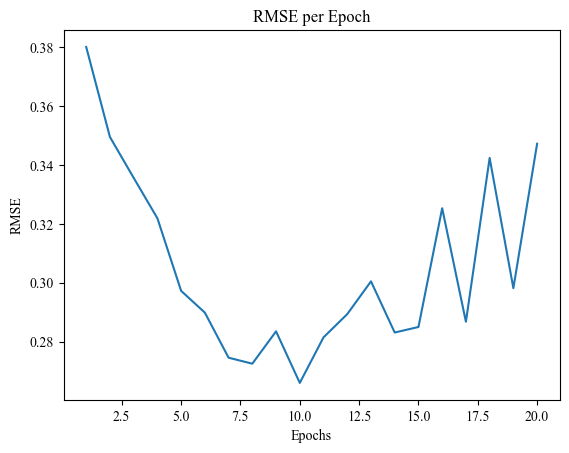

| 1         | -3.691    | 0.7491    | 48.03     | 0.3928    | 33.95     | 93.96     | 93.95     | 37.58     |
Epoch 1/10, RMSE: 0.4573
Epoch 2/10, RMSE: 0.4668
Epoch 3/10, RMSE: 0.4194
Epoch 4/10, RMSE: 0.3737
Epoch 5/10, RMSE: 0.3299
Epoch 6/10, RMSE: 0.3907
Epoch 7/10, RMSE: 0.2897
Epoch 8/10, RMSE: 0.2815
Epoch 9/10, RMSE: 0.2801
Epoch 10/10, RMSE: 0.3046


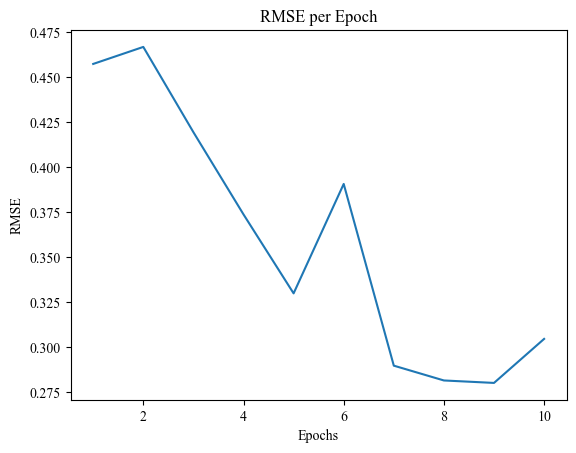

| 2         | -3.09     | 1.732     | 34.04     | 0.3832    | 10.82     | 250.2     | 223.8     | 52.38     |
Epoch 1/30, RMSE: 0.5987
Epoch 2/30, RMSE: 0.4563
Epoch 3/30, RMSE: 0.3363
Epoch 4/30, RMSE: 0.3391
Epoch 5/30, RMSE: 0.3321
Epoch 6/30, RMSE: 0.3616
Epoch 7/30, RMSE: 0.3619
Epoch 8/30, RMSE: 0.3972
Epoch 9/30, RMSE: 0.3879
Epoch 10/30, RMSE: 0.3551
Epoch 11/30, RMSE: 0.3630
Epoch 12/30, RMSE: 0.3954
Epoch 13/30, RMSE: 0.3691
Epoch 14/30, RMSE: 0.3845
Epoch 15/30, RMSE: 0.3873
Early stopping at epoch 15


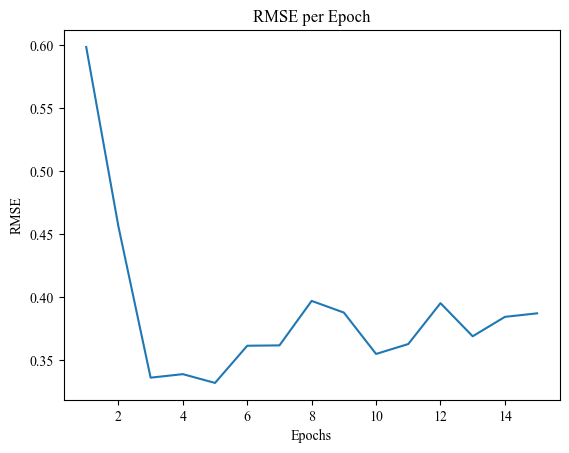

| 3         | -4.05     | 0.3636    | 17.34     | 0.2217    | 30.99     | 146.9     | 119.9     | 90.74     |
Epoch 1/28, RMSE: 0.4673
Epoch 2/28, RMSE: 0.3508
Epoch 3/28, RMSE: 0.3337
Epoch 4/28, RMSE: 0.3391
Epoch 5/28, RMSE: 0.3639
Epoch 6/28, RMSE: 0.3465
Epoch 7/28, RMSE: 0.3495
Epoch 8/28, RMSE: 0.3114
Epoch 9/28, RMSE: 0.3155
Epoch 10/28, RMSE: 0.3919
Epoch 11/28, RMSE: 0.4884
Epoch 12/28, RMSE: 0.3753
Epoch 13/28, RMSE: 0.3798
Epoch 14/28, RMSE: 0.3824
Epoch 15/28, RMSE: 0.3751
Epoch 16/28, RMSE: 0.3573
Epoch 17/28, RMSE: 0.3610
Epoch 18/28, RMSE: 0.3581
Early stopping at epoch 18


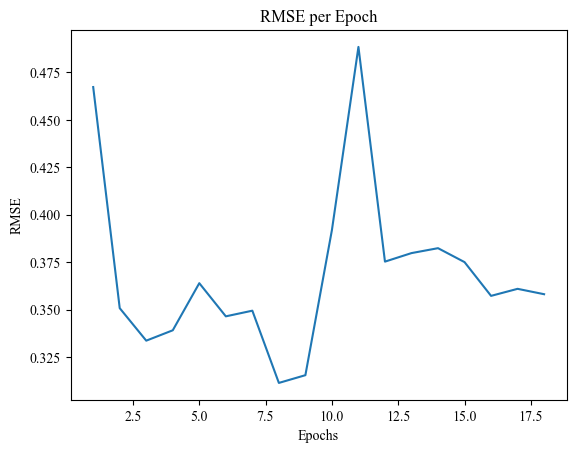

| 4         | -3.633    | 0.279     | 21.69     | 0.2465    | 28.24     | 214.8     | 102.3     | 81.37     |
Epoch 1/16, RMSE: 0.6224
Epoch 2/16, RMSE: 0.5999
Epoch 3/16, RMSE: 0.4160
Epoch 4/16, RMSE: 0.4517
Epoch 5/16, RMSE: 0.3951
Epoch 6/16, RMSE: 0.4021
Epoch 7/16, RMSE: 0.4239
Epoch 8/16, RMSE: 0.3612
Epoch 9/16, RMSE: 0.3744
Epoch 10/16, RMSE: 0.3980
Epoch 11/16, RMSE: 0.3584
Epoch 12/16, RMSE: 0.3938
Epoch 13/16, RMSE: 0.3136
Epoch 14/16, RMSE: 0.3463
Epoch 15/16, RMSE: 0.3506
Epoch 16/16, RMSE: 0.3933


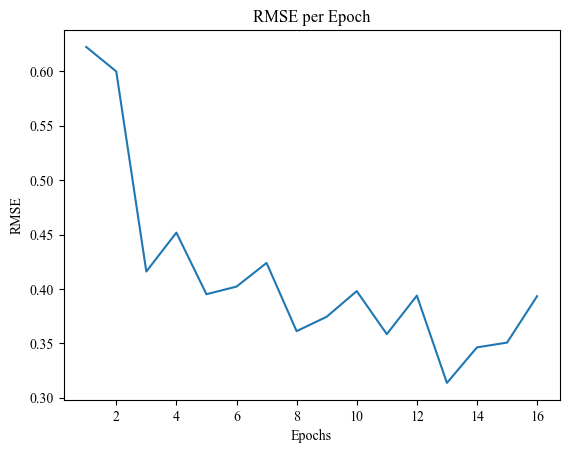

| 5         | -3.977    | 1.185     | 11.86     | 0.343     | 16.82     | 76.49     | 246.2     | 124.7     |
Epoch 1/37, RMSE: 0.4914
Epoch 2/37, RMSE: 0.3865
Epoch 3/37, RMSE: 0.3576
Epoch 4/37, RMSE: 0.3645
Epoch 5/37, RMSE: 0.3560
Epoch 6/37, RMSE: 0.3464
Epoch 7/37, RMSE: 0.3285
Epoch 8/37, RMSE: 0.3098
Epoch 9/37, RMSE: 0.3247
Epoch 10/37, RMSE: 0.3142
Epoch 11/37, RMSE: 0.3449
Epoch 12/37, RMSE: 0.3472
Epoch 13/37, RMSE: 0.3447
Epoch 14/37, RMSE: 0.3967
Epoch 15/37, RMSE: 0.3707
Epoch 16/37, RMSE: 0.3428
Epoch 17/37, RMSE: 0.3788
Epoch 18/37, RMSE: 0.3726
Early stopping at epoch 18


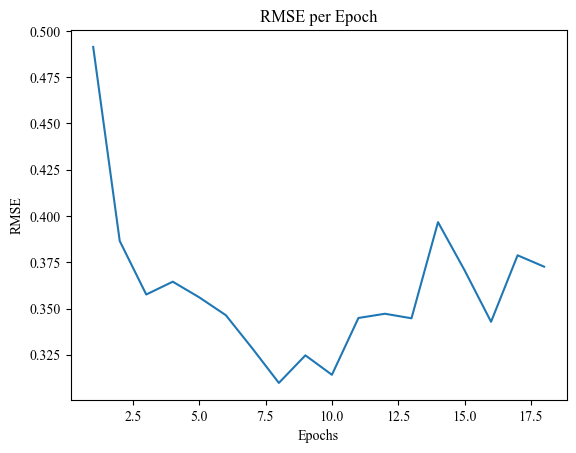

| 6         | -3.854    | 1.617     | 22.18     | 0.1391    | 37.37     | 148.5     | 87.43     | 79.54     |
Epoch 1/36, RMSE: 0.4099
Epoch 2/36, RMSE: 0.3587
Epoch 3/36, RMSE: 0.3391
Epoch 4/36, RMSE: 0.3383
Epoch 5/36, RMSE: 0.3503
Epoch 6/36, RMSE: 0.3273
Epoch 7/36, RMSE: 0.2945
Epoch 8/36, RMSE: 0.3282
Epoch 9/36, RMSE: 0.2960
Epoch 10/36, RMSE: 0.3065
Epoch 11/36, RMSE: 0.2772
Epoch 12/36, RMSE: 0.2805
Epoch 13/36, RMSE: 0.2900
Epoch 14/36, RMSE: 0.2707
Epoch 15/36, RMSE: 0.2705
Epoch 16/36, RMSE: 0.2883
Epoch 17/36, RMSE: 0.2643
Epoch 18/36, RMSE: 0.2726
Epoch 19/36, RMSE: 0.2703
Epoch 20/36, RMSE: 0.2728
Epoch 21/36, RMSE: 0.2966
Epoch 22/36, RMSE: 0.2703
Epoch 23/36, RMSE: 0.2648
Epoch 24/36, RMSE: 0.2792
Epoch 25/36, RMSE: 0.2557
Epoch 26/36, RMSE: 0.2774
Epoch 27/36, RMSE: 0.2755
Epoch 28/36, RMSE: 0.2743
Epoch 29/36, RMSE: 0.2672
Epoch 30/36, RMSE: 0.2603
Epoch 31/36, RMSE: 0.2597
Epoch 32/36, RMSE: 0.2470
Epoch 33/36, RMSE: 0.2739
Epoch 34/36, RMSE: 0.2453
Epoch 35/36, RM

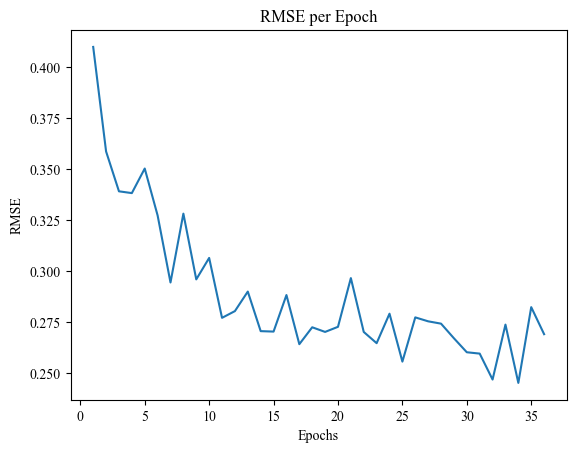

| 7         | -2.837    | 0.06878   | 46.37     | 0.2035    | 36.5      | 123.8     | 163.9     | 84.48     |
Epoch 1/47, RMSE: 0.4500
Epoch 2/47, RMSE: 0.4782
Epoch 3/47, RMSE: 0.3674
Epoch 4/47, RMSE: 0.3694
Epoch 5/47, RMSE: 0.3174
Epoch 6/47, RMSE: 0.3194
Epoch 7/47, RMSE: 0.2906
Epoch 8/47, RMSE: 0.2828
Epoch 9/47, RMSE: 0.2859
Epoch 10/47, RMSE: 0.2957
Epoch 11/47, RMSE: 0.3131
Epoch 12/47, RMSE: 0.3659
Epoch 13/47, RMSE: 0.2887
Epoch 14/47, RMSE: 0.3161
Epoch 15/47, RMSE: 0.2899
Epoch 16/47, RMSE: 0.3396
Epoch 17/47, RMSE: 0.3419
Epoch 18/47, RMSE: 0.3044
Early stopping at epoch 18


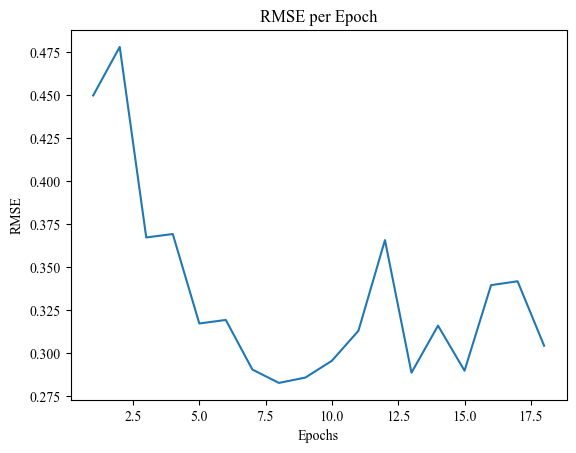

| 8         | -3.139    | 0.3697    | 48.78     | 0.4101    | 47.58     | 235.8     | 178.8     | 120.5     |
Epoch 1/23, RMSE: 0.6505
Epoch 2/23, RMSE: 0.4434
Epoch 3/23, RMSE: 0.3590
Epoch 4/23, RMSE: 0.3512
Epoch 5/23, RMSE: 0.3616
Epoch 6/23, RMSE: 0.3624
Epoch 7/23, RMSE: 0.3314
Epoch 8/23, RMSE: 0.3377
Epoch 9/23, RMSE: 0.3210
Epoch 10/23, RMSE: 0.3226
Epoch 11/23, RMSE: 0.3197
Epoch 12/23, RMSE: 0.3424
Epoch 13/23, RMSE: 0.3195
Epoch 14/23, RMSE: 0.3482
Epoch 15/23, RMSE: 0.3738
Epoch 16/23, RMSE: 0.4144
Epoch 17/23, RMSE: 0.4322
Epoch 18/23, RMSE: 0.4092
Epoch 19/23, RMSE: 0.4053
Epoch 20/23, RMSE: 0.4085
Epoch 21/23, RMSE: 0.3736
Epoch 22/23, RMSE: 0.3767
Epoch 23/23, RMSE: 0.3808
Early stopping at epoch 23


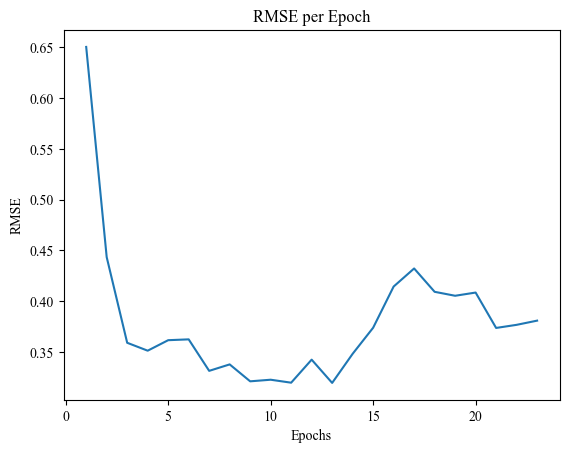

| 9         | -3.916    | 0.177     | 17.84     | 0.1181    | 23.01     | 138.6     | 116.1     | 111.6     |
Epoch 1/15, RMSE: 0.5282
Epoch 2/15, RMSE: 0.3917
Epoch 3/15, RMSE: 0.3734
Epoch 4/15, RMSE: 0.3479
Epoch 5/15, RMSE: 0.3690
Epoch 6/15, RMSE: 0.3400
Epoch 7/15, RMSE: 0.3374
Epoch 8/15, RMSE: 0.3353
Epoch 9/15, RMSE: 0.3826
Epoch 10/15, RMSE: 0.3558
Epoch 11/15, RMSE: 0.3739
Epoch 12/15, RMSE: 0.3941
Epoch 13/15, RMSE: 0.3987
Epoch 14/15, RMSE: 0.4169
Epoch 15/15, RMSE: 0.4209


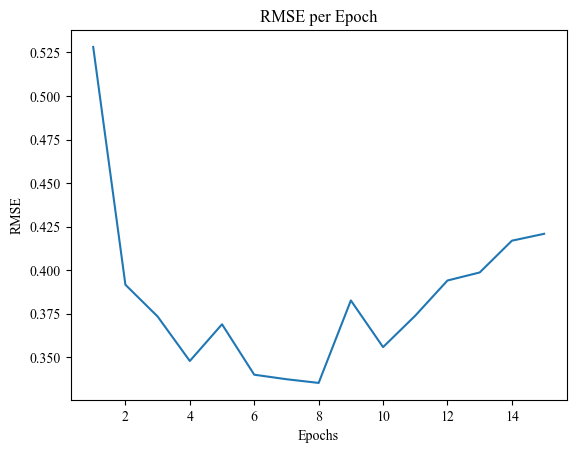

| 10        | -4.048    | 0.7135    | 21.24     | 0.3171    | 15.64     | 218.0     | 78.31     | 126.7     |
Epoch 1/35, RMSE: 0.4005
Epoch 2/35, RMSE: 0.4262
Epoch 3/35, RMSE: 0.3782
Epoch 4/35, RMSE: 0.3788
Epoch 5/35, RMSE: 0.3274
Epoch 6/35, RMSE: 0.2859
Epoch 7/35, RMSE: 0.3061
Epoch 8/35, RMSE: 0.2876
Epoch 9/35, RMSE: 0.2818
Epoch 10/35, RMSE: 0.2984
Epoch 11/35, RMSE: 0.2979
Epoch 12/35, RMSE: 0.2774
Epoch 13/35, RMSE: 0.2689
Epoch 14/35, RMSE: 0.2664
Epoch 15/35, RMSE: 0.2931
Epoch 16/35, RMSE: 0.2562
Epoch 17/35, RMSE: 0.2645
Epoch 18/35, RMSE: 0.2641
Epoch 19/35, RMSE: 0.2879
Epoch 20/35, RMSE: 0.2777
Epoch 21/35, RMSE: 0.2676
Epoch 22/35, RMSE: 0.2592
Epoch 23/35, RMSE: 0.2610
Epoch 24/35, RMSE: 0.2650
Epoch 25/35, RMSE: 0.2813
Epoch 26/35, RMSE: 0.2413
Epoch 27/35, RMSE: 0.2558
Epoch 28/35, RMSE: 0.2634
Epoch 29/35, RMSE: 0.2770
Epoch 30/35, RMSE: 0.2654
Epoch 31/35, RMSE: 0.2446
Epoch 32/35, RMSE: 0.2735
Epoch 33/35, RMSE: 0.2632
Epoch 34/35, RMSE: 0.2491
Epoch 35/35, RM

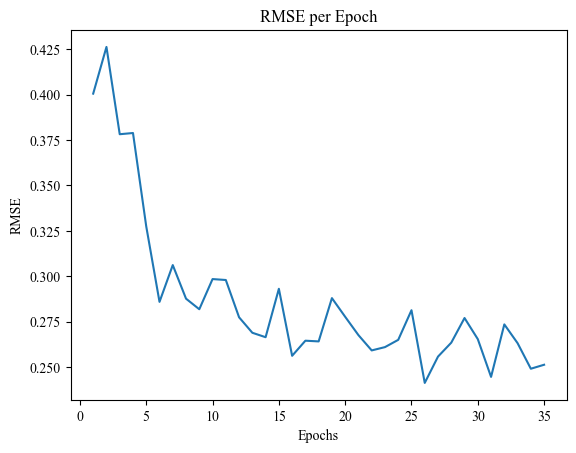

| 11        | -2.849    | 0.1165    | 49.2      | 0.1975    | 35.41     | 135.9     | 186.8     | 89.22     |
Epoch 1/40, RMSE: 0.4019
Epoch 2/40, RMSE: 0.3987
Epoch 3/40, RMSE: 0.3266
Epoch 4/40, RMSE: 0.3174
Epoch 5/40, RMSE: 0.3012
Epoch 6/40, RMSE: 0.3047
Epoch 7/40, RMSE: 0.2784
Epoch 8/40, RMSE: 0.2719
Epoch 9/40, RMSE: 0.2872
Epoch 10/40, RMSE: 0.2656
Epoch 11/40, RMSE: 0.2657
Epoch 12/40, RMSE: 0.2653
Epoch 13/40, RMSE: 0.2616
Epoch 14/40, RMSE: 0.3242
Epoch 15/40, RMSE: 0.2823
Epoch 16/40, RMSE: 0.2638
Epoch 17/40, RMSE: 0.2718
Epoch 18/40, RMSE: 0.2668
Epoch 19/40, RMSE: 0.2936
Epoch 20/40, RMSE: 0.2736
Epoch 21/40, RMSE: 0.3123
Epoch 22/40, RMSE: 0.3073
Epoch 23/40, RMSE: 0.2721
Early stopping at epoch 23


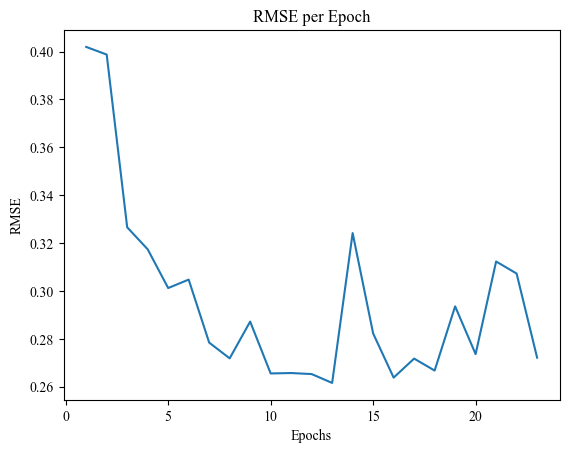

| 12        | -2.92     | 1.333     | 45.77     | 0.3375    | 40.07     | 124.8     | 164.3     | 80.4      |
Epoch 1/13, RMSE: 0.4100
Epoch 2/13, RMSE: 0.3768
Epoch 3/13, RMSE: 0.3331
Epoch 4/13, RMSE: 0.3307
Epoch 5/13, RMSE: 0.3013
Epoch 6/13, RMSE: 0.2857
Epoch 7/13, RMSE: 0.2880
Epoch 8/13, RMSE: 0.2846
Epoch 9/13, RMSE: 0.2878
Epoch 10/13, RMSE: 0.2713
Epoch 11/13, RMSE: 0.2617
Epoch 12/13, RMSE: 0.2671
Epoch 13/13, RMSE: 0.2740


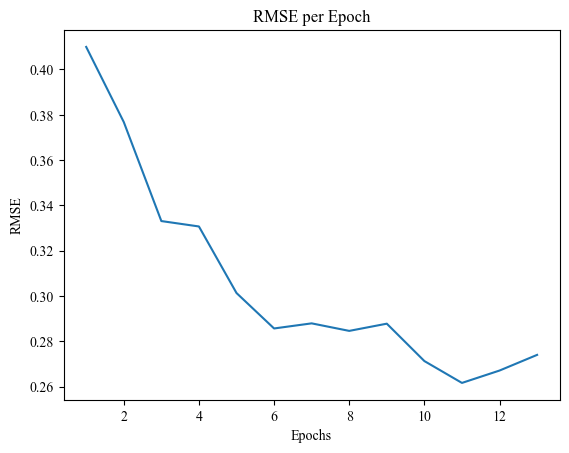

| 13        | -2.877    | 0.2431    | 49.1      | 0.1674    | 13.53     | 87.94     | 171.8     | 89.43     |
Epoch 1/40, RMSE: 0.3811
Epoch 2/40, RMSE: 0.3847
Epoch 3/40, RMSE: 0.3580
Epoch 4/40, RMSE: 0.3488
Epoch 5/40, RMSE: 0.3173
Epoch 6/40, RMSE: 0.3132
Epoch 7/40, RMSE: 0.2752
Epoch 8/40, RMSE: 0.2883
Epoch 9/40, RMSE: 0.2726
Epoch 10/40, RMSE: 0.2767
Epoch 11/40, RMSE: 0.2754
Epoch 12/40, RMSE: 0.2601
Epoch 13/40, RMSE: 0.2683
Epoch 14/40, RMSE: 0.2618
Epoch 15/40, RMSE: 0.2694
Epoch 16/40, RMSE: 0.3087
Epoch 17/40, RMSE: 0.2585
Epoch 18/40, RMSE: 0.2605
Epoch 19/40, RMSE: 0.2694
Epoch 20/40, RMSE: 0.2526
Epoch 21/40, RMSE: 0.2682
Epoch 22/40, RMSE: 0.3117
Epoch 23/40, RMSE: 0.2552
Epoch 24/40, RMSE: 0.2851
Epoch 25/40, RMSE: 0.2449
Epoch 26/40, RMSE: 0.2683
Epoch 27/40, RMSE: 0.2565
Epoch 28/40, RMSE: 0.2760
Epoch 29/40, RMSE: 0.2892
Epoch 30/40, RMSE: 0.2717
Epoch 31/40, RMSE: 0.2583
Epoch 32/40, RMSE: 0.2990
Epoch 33/40, RMSE: 0.3086
Epoch 34/40, RMSE: 0.2502
Epoch 35/40, RM

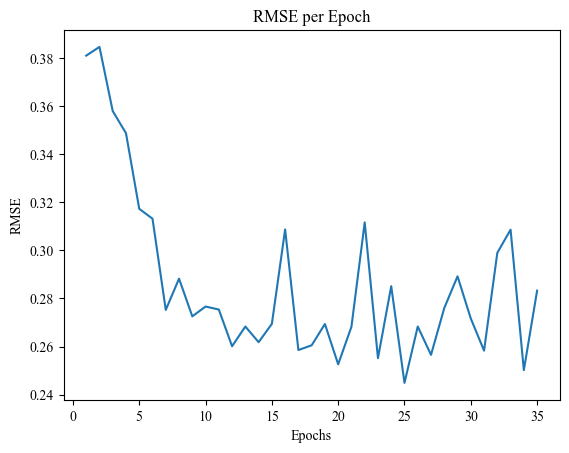

| 14        | -3.041    | 1.492     | 49.45     | 0.2224    | 40.95     | 109.4     | 155.8     | 122.8     |
Epoch 1/19, RMSE: 0.4518
Epoch 2/19, RMSE: 0.4056
Epoch 3/19, RMSE: 0.3666
Epoch 4/19, RMSE: 0.3609
Epoch 5/19, RMSE: 0.3279
Epoch 6/19, RMSE: 0.3240
Epoch 7/19, RMSE: 0.2892
Epoch 8/19, RMSE: 0.2848
Epoch 9/19, RMSE: 0.2995
Epoch 10/19, RMSE: 0.2849
Epoch 11/19, RMSE: 0.3010
Epoch 12/19, RMSE: 0.2679
Epoch 13/19, RMSE: 0.2791
Epoch 14/19, RMSE: 0.2966
Epoch 15/19, RMSE: 0.2897
Epoch 16/19, RMSE: 0.2693
Epoch 17/19, RMSE: 0.3015
Epoch 18/19, RMSE: 0.3062
Epoch 19/19, RMSE: 0.2878


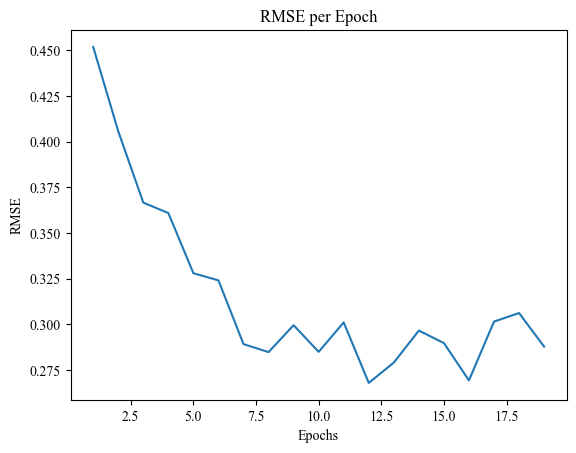

| 15        | -2.894    | 1.775     | 48.5      | 0.2723    | 19.42     | 197.0     | 231.0     | 96.15     |
Epoch 1/29, RMSE: 0.4640
Epoch 2/29, RMSE: 0.4145
Epoch 3/29, RMSE: 0.4128
Epoch 4/29, RMSE: 0.3212
Epoch 5/29, RMSE: 0.2952
Epoch 6/29, RMSE: 0.3287
Epoch 7/29, RMSE: 0.3360
Epoch 8/29, RMSE: 0.3104
Epoch 9/29, RMSE: 0.3079
Epoch 10/29, RMSE: 0.2819
Epoch 11/29, RMSE: 0.2987
Epoch 12/29, RMSE: 0.2895
Epoch 13/29, RMSE: 0.2630
Epoch 14/29, RMSE: 0.2706
Epoch 15/29, RMSE: 0.2720
Epoch 16/29, RMSE: 0.2634
Epoch 17/29, RMSE: 0.2738
Epoch 18/29, RMSE: 0.2640
Epoch 19/29, RMSE: 0.2623
Epoch 20/29, RMSE: 0.3128
Epoch 21/29, RMSE: 0.2734
Epoch 22/29, RMSE: 0.2902
Epoch 23/29, RMSE: 0.2551
Epoch 24/29, RMSE: 0.2891
Epoch 25/29, RMSE: 0.2670
Epoch 26/29, RMSE: 0.3056
Epoch 27/29, RMSE: 0.2687
Epoch 28/29, RMSE: 0.2863
Epoch 29/29, RMSE: 0.2705


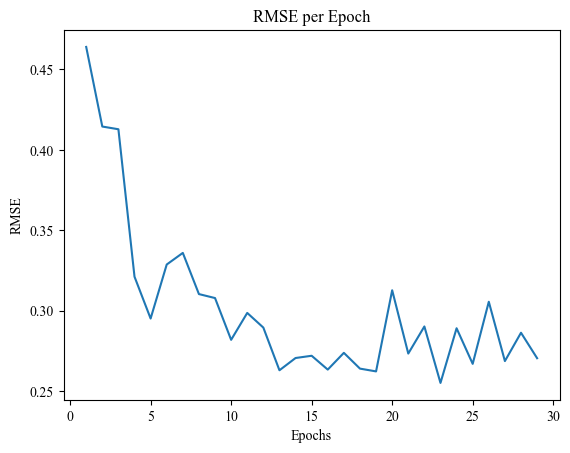

| 16        | -2.925    | 0.6146    | 46.46     | 0.2526    | 29.97     | 250.9     | 251.9     | 126.2     |
Epoch 1/43, RMSE: 0.7994
Epoch 2/43, RMSE: 0.5125
Epoch 3/43, RMSE: 0.4615
Epoch 4/43, RMSE: 0.4794
Epoch 5/43, RMSE: 0.5002
Epoch 6/43, RMSE: 0.4773
Epoch 7/43, RMSE: 0.4512
Epoch 8/43, RMSE: 0.4708
Epoch 9/43, RMSE: 0.4134
Epoch 10/43, RMSE: 0.3794
Epoch 11/43, RMSE: 0.3766
Epoch 12/43, RMSE: 0.4083
Epoch 13/43, RMSE: 0.3565
Epoch 14/43, RMSE: 0.3230
Epoch 15/43, RMSE: 0.3514
Epoch 16/43, RMSE: 0.3427
Epoch 17/43, RMSE: 0.3610
Epoch 18/43, RMSE: 0.3477
Epoch 19/43, RMSE: 0.3558
Epoch 20/43, RMSE: 0.3802
Epoch 21/43, RMSE: 0.3412
Epoch 22/43, RMSE: 0.3768
Epoch 23/43, RMSE: 0.3274
Epoch 24/43, RMSE: 0.3607
Early stopping at epoch 24


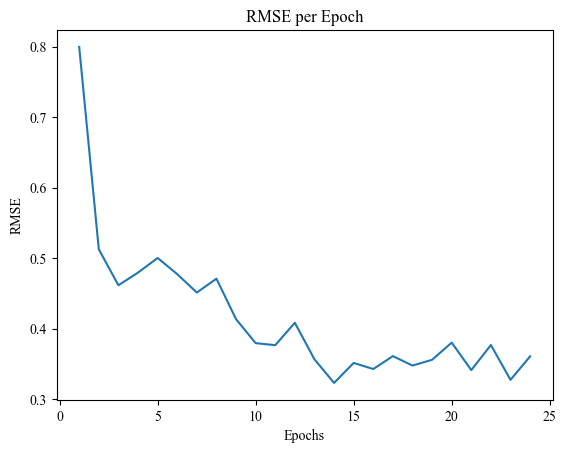

| 17        | -3.58     | 1.699     | 10.8      | 0.4859    | 43.38     | 229.5     | 250.6     | 95.69     |
Epoch 1/12, RMSE: 0.3908
Epoch 2/12, RMSE: 0.3814
Epoch 3/12, RMSE: 0.3485
Epoch 4/12, RMSE: 0.3357
Epoch 5/12, RMSE: 0.3085
Epoch 6/12, RMSE: 0.3034
Epoch 7/12, RMSE: 0.2956
Epoch 8/12, RMSE: 0.2907
Epoch 9/12, RMSE: 0.2780
Epoch 10/12, RMSE: 0.2869
Epoch 11/12, RMSE: 0.2733
Epoch 12/12, RMSE: 0.2706


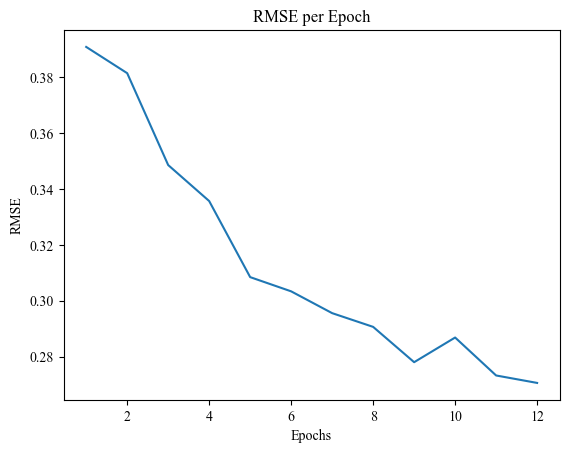

| 18        | -2.874    | 1.671     | 45.28     | 0.3718    | 12.48     | 149.7     | 237.0     | 35.57     |
Epoch 1/16, RMSE: 0.4027
Epoch 2/16, RMSE: 0.3764
Epoch 3/16, RMSE: 0.3326
Epoch 4/16, RMSE: 0.3464
Epoch 5/16, RMSE: 0.3066
Epoch 6/16, RMSE: 0.2967
Epoch 7/16, RMSE: 0.2852
Epoch 8/16, RMSE: 0.3053
Epoch 9/16, RMSE: 0.3049
Epoch 10/16, RMSE: 0.2803
Epoch 11/16, RMSE: 0.2771
Epoch 12/16, RMSE: 0.2792
Epoch 13/16, RMSE: 0.2812
Epoch 14/16, RMSE: 0.2810
Epoch 15/16, RMSE: 0.2645
Epoch 16/16, RMSE: 0.2599


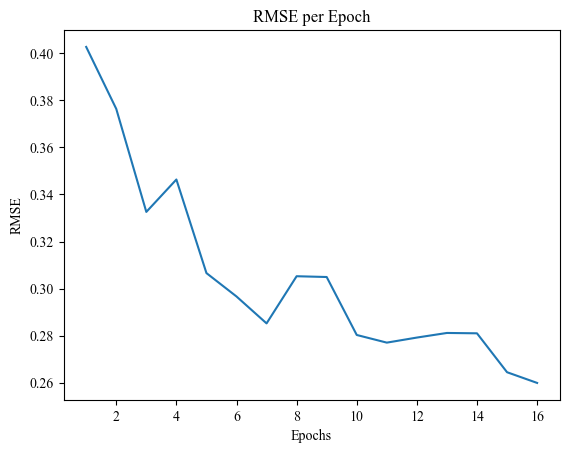

| 19        | -2.964    | 0.192     | 48.7      | 0.3124    | 16.72     | 186.8     | 197.9     | 33.73     |
Epoch 1/13, RMSE: 0.3749
Epoch 2/13, RMSE: 0.3633
Epoch 3/13, RMSE: 0.3650
Epoch 4/13, RMSE: 0.3496
Epoch 5/13, RMSE: 0.3225
Epoch 6/13, RMSE: 0.3146
Epoch 7/13, RMSE: 0.2973
Epoch 8/13, RMSE: 0.2767
Epoch 9/13, RMSE: 0.2865
Epoch 10/13, RMSE: 0.3101
Epoch 11/13, RMSE: 0.2723
Epoch 12/13, RMSE: 0.2928
Epoch 13/13, RMSE: 0.2565


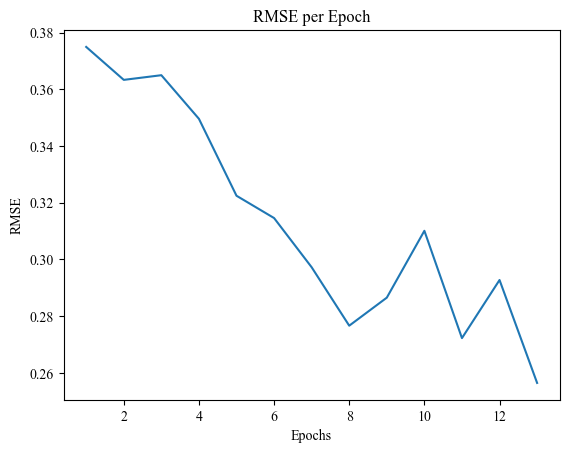

| 20        | -2.898    | 0.2314    | 49.0      | 0.3046    | 13.1      | 119.5     | 195.2     | 39.28     |
Epoch 1/41, RMSE: 0.3768
Epoch 2/41, RMSE: 0.3532
Epoch 3/41, RMSE: 0.3518
Epoch 4/41, RMSE: 0.3528
Epoch 5/41, RMSE: 0.3431
Epoch 6/41, RMSE: 0.3443
Epoch 7/41, RMSE: 0.3343
Epoch 8/41, RMSE: 0.3250
Epoch 9/41, RMSE: 0.2815
Epoch 10/41, RMSE: 0.2942
Epoch 11/41, RMSE: 0.2962
Epoch 12/41, RMSE: 0.3150
Epoch 13/41, RMSE: 0.2892
Epoch 14/41, RMSE: 0.2940
Epoch 15/41, RMSE: 0.2811
Epoch 16/41, RMSE: 0.2633
Epoch 17/41, RMSE: 0.2757
Epoch 18/41, RMSE: 0.2668
Epoch 19/41, RMSE: 0.2810
Epoch 20/41, RMSE: 0.2605
Epoch 21/41, RMSE: 0.2889
Epoch 22/41, RMSE: 0.2542
Epoch 23/41, RMSE: 0.2670
Epoch 24/41, RMSE: 0.2678
Epoch 25/41, RMSE: 0.2846
Epoch 26/41, RMSE: 0.2631
Epoch 27/41, RMSE: 0.3060
Epoch 28/41, RMSE: 0.2536
Epoch 29/41, RMSE: 0.2486
Epoch 30/41, RMSE: 0.2611
Epoch 31/41, RMSE: 0.2568
Epoch 32/41, RMSE: 0.2708
Epoch 33/41, RMSE: 0.2572
Epoch 34/41, RMSE: 0.2532
Epoch 35/41, RM

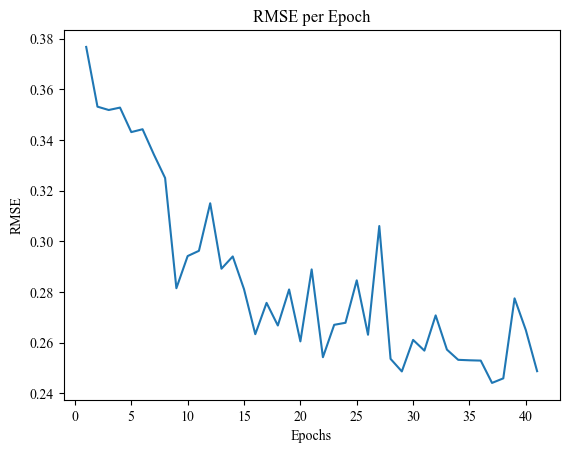

| 21        | -2.632    | 0.3757    | 42.25     | 0.105     | 41.57     | 256.0     | 159.3     | 36.67     |
Epoch 1/48, RMSE: 0.3780
Epoch 2/48, RMSE: 0.3741
Epoch 3/48, RMSE: 0.3313
Epoch 4/48, RMSE: 0.3465
Epoch 5/48, RMSE: 0.3049
Epoch 6/48, RMSE: 0.3163
Epoch 7/48, RMSE: 0.2864
Epoch 8/48, RMSE: 0.2939
Epoch 9/48, RMSE: 0.2865
Epoch 10/48, RMSE: 0.2800
Epoch 11/48, RMSE: 0.2936
Epoch 12/48, RMSE: 0.2664
Epoch 13/48, RMSE: 0.2714
Epoch 14/48, RMSE: 0.2827
Epoch 15/48, RMSE: 0.2683
Epoch 16/48, RMSE: 0.2632
Epoch 17/48, RMSE: 0.2669
Epoch 18/48, RMSE: 0.2925
Epoch 19/48, RMSE: 0.3134
Epoch 20/48, RMSE: 0.2636
Epoch 21/48, RMSE: 0.2725
Epoch 22/48, RMSE: 0.2739
Epoch 23/48, RMSE: 0.2801
Epoch 24/48, RMSE: 0.2583
Epoch 25/48, RMSE: 0.2984
Epoch 26/48, RMSE: 0.2554
Epoch 27/48, RMSE: 0.2752
Epoch 28/48, RMSE: 0.2714
Epoch 29/48, RMSE: 0.2890
Epoch 30/48, RMSE: 0.2615
Epoch 31/48, RMSE: 0.2885
Epoch 32/48, RMSE: 0.3107
Epoch 33/48, RMSE: 0.2648
Epoch 34/48, RMSE: 0.2771
Epoch 35/48, RM

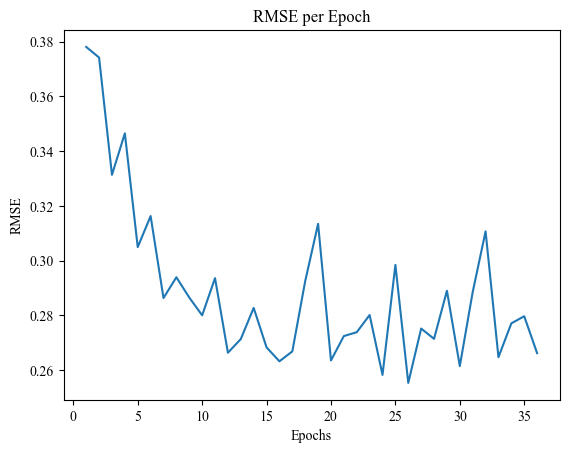

| 22        | -2.999    | 1.653     | 47.49     | 0.3372    | 48.32     | 248.6     | 117.0     | 32.16     |
Epoch 1/11, RMSE: 0.4070
Epoch 2/11, RMSE: 0.3900
Epoch 3/11, RMSE: 0.3759
Epoch 4/11, RMSE: 0.3434
Epoch 5/11, RMSE: 0.3376
Epoch 6/11, RMSE: 0.3001
Epoch 7/11, RMSE: 0.3046
Epoch 8/11, RMSE: 0.2971
Epoch 9/11, RMSE: 0.2844
Epoch 10/11, RMSE: 0.2995
Epoch 11/11, RMSE: 0.2813


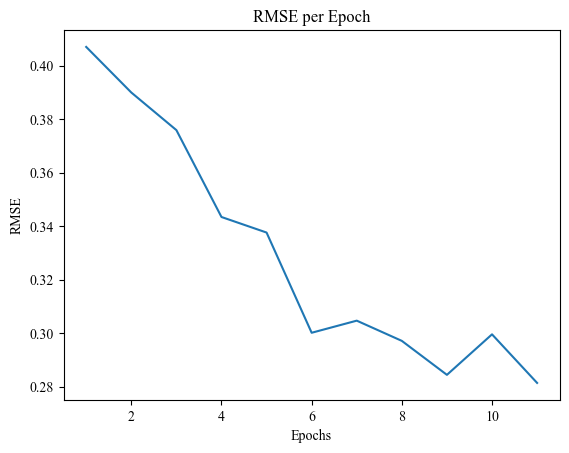

| 23        | -3.007    | 0.7391    | 47.33     | 0.1832    | 11.87     | 249.1     | 156.3     | 46.91     |
Epoch 1/46, RMSE: 0.6387
Epoch 2/46, RMSE: 0.4759
Epoch 3/46, RMSE: 0.4179
Epoch 4/46, RMSE: 0.3506
Epoch 5/46, RMSE: 0.3688
Epoch 6/46, RMSE: 0.3488
Epoch 7/46, RMSE: 0.3337
Epoch 8/46, RMSE: 0.3114
Epoch 9/46, RMSE: 0.2973
Epoch 10/46, RMSE: 0.3006
Epoch 11/46, RMSE: 0.2960
Epoch 12/46, RMSE: 0.3223
Epoch 13/46, RMSE: 0.3046
Epoch 14/46, RMSE: 0.3804
Epoch 15/46, RMSE: 0.3642
Epoch 16/46, RMSE: 0.3561
Epoch 17/46, RMSE: 0.3497
Epoch 18/46, RMSE: 0.3793
Epoch 19/46, RMSE: 0.3976
Epoch 20/46, RMSE: 0.4058
Epoch 21/46, RMSE: 0.4183
Early stopping at epoch 21


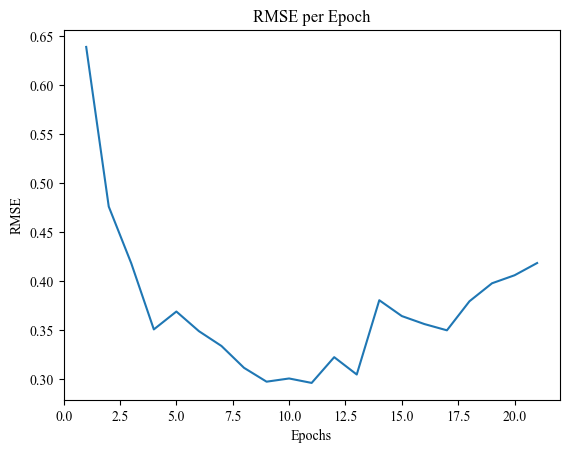

| 24        | -4.449    | 1.338     | 16.0      | 0.1304    | 46.45     | 254.3     | 177.2     | 36.73     |
Epoch 1/24, RMSE: 0.3689
Epoch 2/24, RMSE: 0.3886
Epoch 3/24, RMSE: 0.3350
Epoch 4/24, RMSE: 0.3908
Epoch 5/24, RMSE: 0.3128
Epoch 6/24, RMSE: 0.2994
Epoch 7/24, RMSE: 0.2956
Epoch 8/24, RMSE: 0.2800
Epoch 9/24, RMSE: 0.2755
Epoch 10/24, RMSE: 0.2674
Epoch 11/24, RMSE: 0.2681
Epoch 12/24, RMSE: 0.2704
Epoch 13/24, RMSE: 0.2554
Epoch 14/24, RMSE: 0.2682
Epoch 15/24, RMSE: 0.2671
Epoch 16/24, RMSE: 0.2646
Epoch 17/24, RMSE: 0.2773
Epoch 18/24, RMSE: 0.2867
Epoch 19/24, RMSE: 0.3110
Epoch 20/24, RMSE: 0.2750
Epoch 21/24, RMSE: 0.3053
Epoch 22/24, RMSE: 0.3625
Epoch 23/24, RMSE: 0.2877
Early stopping at epoch 23


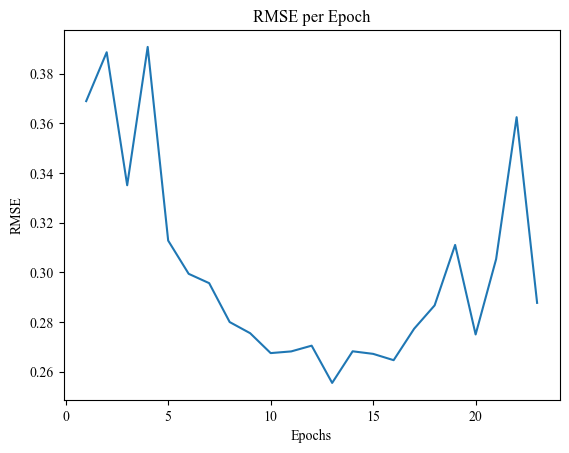

| 25        | -3.13     | 1.3       | 47.28     | 0.3763    | 24.69     | 166.8     | 214.0     | 66.74     |
Epoch 1/42, RMSE: 0.3835
Epoch 2/42, RMSE: 0.3873
Epoch 3/42, RMSE: 0.3355
Epoch 4/42, RMSE: 0.4204
Epoch 5/42, RMSE: 0.3018
Epoch 6/42, RMSE: 0.3062
Epoch 7/42, RMSE: 0.3103
Epoch 8/42, RMSE: 0.3032
Epoch 9/42, RMSE: 0.2937
Epoch 10/42, RMSE: 0.2961
Epoch 11/42, RMSE: 0.2708
Epoch 12/42, RMSE: 0.2621
Epoch 13/42, RMSE: 0.2802
Epoch 14/42, RMSE: 0.2794
Epoch 15/42, RMSE: 0.3092
Epoch 16/42, RMSE: 0.2836
Epoch 17/42, RMSE: 0.2758
Epoch 18/42, RMSE: 0.2784
Epoch 19/42, RMSE: 0.2910
Epoch 20/42, RMSE: 0.3250
Epoch 21/42, RMSE: 0.3128
Epoch 22/42, RMSE: 0.2594
Epoch 23/42, RMSE: 0.3045
Epoch 24/42, RMSE: 0.2655
Epoch 25/42, RMSE: 0.2779
Epoch 26/42, RMSE: 0.2787
Epoch 27/42, RMSE: 0.2629
Epoch 28/42, RMSE: 0.2815
Epoch 29/42, RMSE: 0.2690
Epoch 30/42, RMSE: 0.2938
Epoch 31/42, RMSE: 0.2631
Epoch 32/42, RMSE: 0.2871
Early stopping at epoch 32


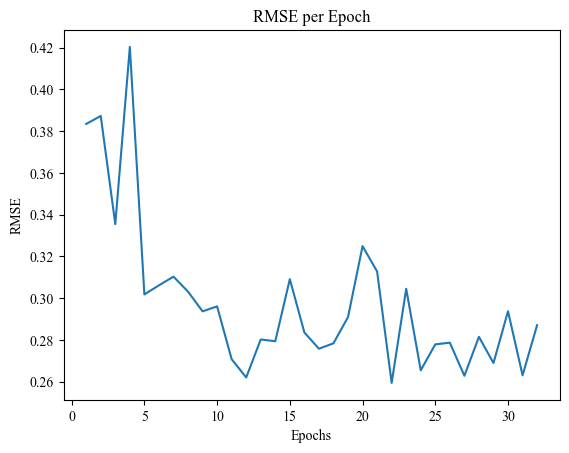

| 26        | -3.085    | 0.8444    | 46.57     | 0.3523    | 42.76     | 248.2     | 147.3     | 52.86     |
Epoch 1/26, RMSE: 0.4141
Epoch 2/26, RMSE: 0.3690
Epoch 3/26, RMSE: 0.3648
Epoch 4/26, RMSE: 0.3265
Epoch 5/26, RMSE: 0.3066
Epoch 6/26, RMSE: 0.2943
Epoch 7/26, RMSE: 0.3279
Epoch 8/26, RMSE: 0.2915
Epoch 9/26, RMSE: 0.2841
Epoch 10/26, RMSE: 0.2624
Epoch 11/26, RMSE: 0.2984
Epoch 12/26, RMSE: 0.2723
Epoch 13/26, RMSE: 0.2576
Epoch 14/26, RMSE: 0.2674
Epoch 15/26, RMSE: 0.2725
Epoch 16/26, RMSE: 0.2708
Epoch 17/26, RMSE: 0.2792
Epoch 18/26, RMSE: 0.2738
Epoch 19/26, RMSE: 0.2906
Epoch 20/26, RMSE: 0.2988
Epoch 21/26, RMSE: 0.3055
Epoch 22/26, RMSE: 0.2719
Epoch 23/26, RMSE: 0.2948
Early stopping at epoch 23


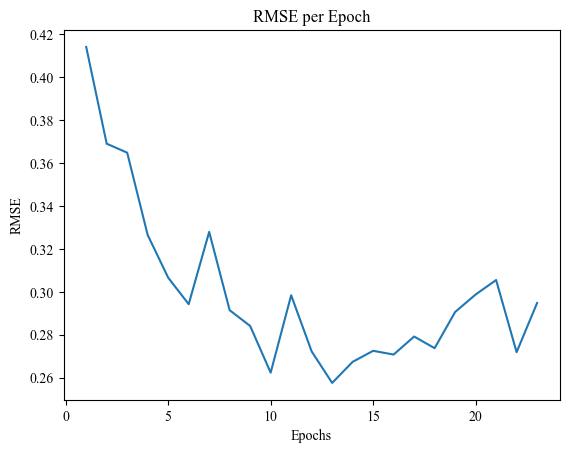

| 27        | -3.16     | 1.646     | 43.65     | 0.1974    | 27.0      | 110.8     | 196.5     | 76.48     |
Epoch 1/20, RMSE: 0.4444
Epoch 2/20, RMSE: 0.3872
Epoch 3/20, RMSE: 0.3690
Epoch 4/20, RMSE: 0.3304
Epoch 5/20, RMSE: 0.3354
Epoch 6/20, RMSE: 0.3439
Epoch 7/20, RMSE: 0.2901
Epoch 8/20, RMSE: 0.2876
Epoch 9/20, RMSE: 0.3239
Epoch 10/20, RMSE: 0.3872
Epoch 11/20, RMSE: 0.4011
Epoch 12/20, RMSE: 0.3722
Epoch 13/20, RMSE: 0.4410
Epoch 14/20, RMSE: 0.3754
Epoch 15/20, RMSE: 0.3650
Epoch 16/20, RMSE: 0.3498
Epoch 17/20, RMSE: 0.3927
Epoch 18/20, RMSE: 0.3616
Early stopping at epoch 18


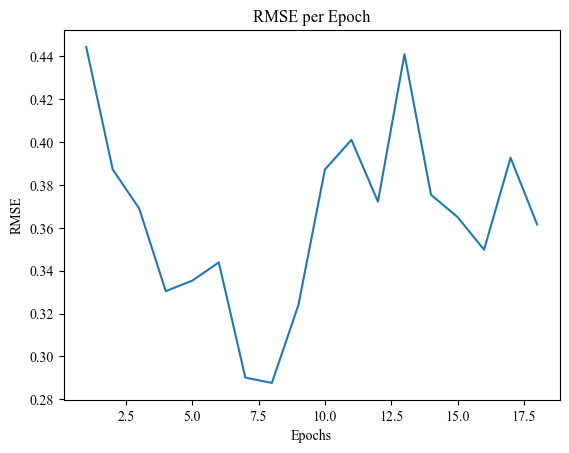

| 28        | -3.608    | 0.8504    | 25.13     | 0.431     | 20.48     | 147.8     | 199.4     | 32.54     |
Epoch 1/13, RMSE: 0.4088
Epoch 2/13, RMSE: 0.3710
Epoch 3/13, RMSE: 0.3613
Epoch 4/13, RMSE: 0.3125
Epoch 5/13, RMSE: 0.2841
Epoch 6/13, RMSE: 0.3087
Epoch 7/13, RMSE: 0.2862
Epoch 8/13, RMSE: 0.2855
Epoch 9/13, RMSE: 0.2855
Epoch 10/13, RMSE: 0.2830
Epoch 11/13, RMSE: 0.2643
Epoch 12/13, RMSE: 0.2616
Epoch 13/13, RMSE: 0.2830


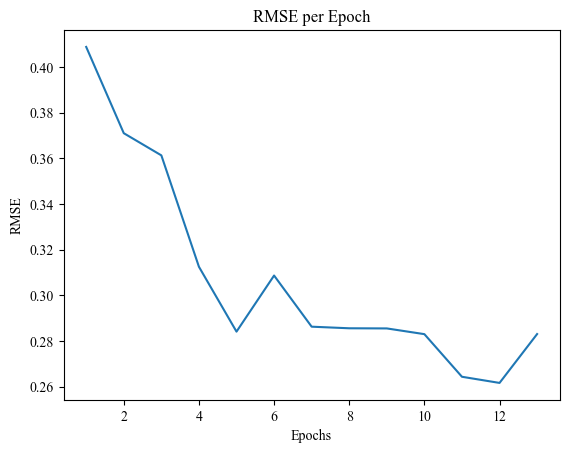

| 29        | -2.904    | 1.348     | 46.64     | 0.3372    | 13.48     | 120.6     | 166.0     | 110.5     |
Epoch 1/11, RMSE: 0.4267
Epoch 2/11, RMSE: 0.3966
Epoch 3/11, RMSE: 0.3603
Epoch 4/11, RMSE: 0.3680
Epoch 5/11, RMSE: 0.3255
Epoch 6/11, RMSE: 0.2952
Epoch 7/11, RMSE: 0.2963
Epoch 8/11, RMSE: 0.2922
Epoch 9/11, RMSE: 0.2904
Epoch 10/11, RMSE: 0.2810
Epoch 11/11, RMSE: 0.2846


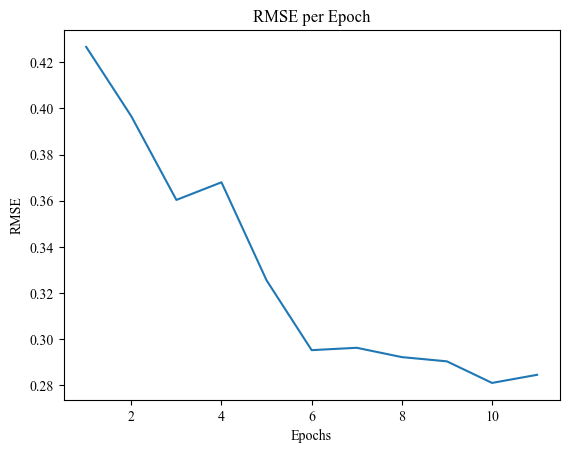

| 30        | -2.962    | 0.9542    | 48.43     | 0.204     | 11.97     | 118.9     | 158.3     | 62.19     |
Epoch 1/13, RMSE: 0.5410
Epoch 2/13, RMSE: 0.3647
Epoch 3/13, RMSE: 0.3594
Epoch 4/13, RMSE: 0.3070
Epoch 5/13, RMSE: 0.3098
Epoch 6/13, RMSE: 0.2912
Epoch 7/13, RMSE: 0.2775
Epoch 8/13, RMSE: 0.2850
Epoch 9/13, RMSE: 0.2960
Epoch 10/13, RMSE: 0.2824
Epoch 11/13, RMSE: 0.2854
Epoch 12/13, RMSE: 0.2773
Epoch 13/13, RMSE: 0.2691


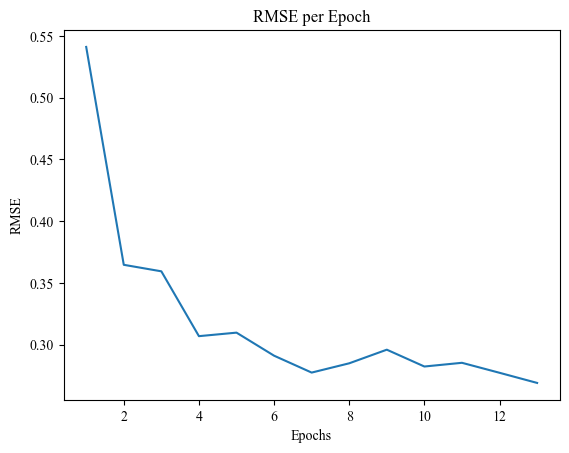

| 31        | -2.89     | 0.1581    | 49.68     | 0.3902    | 13.38     | 203.2     | 232.0     | 44.86     |
Epoch 1/12, RMSE: 0.4361
Epoch 2/12, RMSE: 0.3495
Epoch 3/12, RMSE: 0.3540
Epoch 4/12, RMSE: 0.3336
Epoch 5/12, RMSE: 0.3495
Epoch 6/12, RMSE: 0.3096
Epoch 7/12, RMSE: 0.3293
Epoch 8/12, RMSE: 0.3025
Epoch 9/12, RMSE: 0.2959
Epoch 10/12, RMSE: 0.2874
Epoch 11/12, RMSE: 0.2791
Epoch 12/12, RMSE: 0.2778


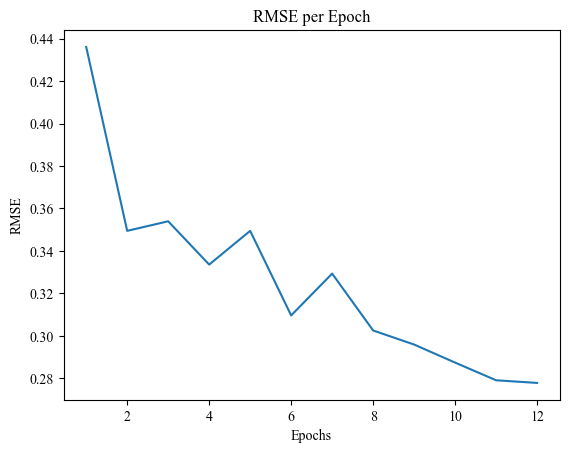

| 32        | -3.082    | 1.458     | 41.47     | 0.1402    | 12.87     | 175.4     | 251.0     | 50.53     |
Epoch 1/10, RMSE: 0.3824
Epoch 2/10, RMSE: 0.3772
Epoch 3/10, RMSE: 0.3375
Epoch 4/10, RMSE: 0.3162
Epoch 5/10, RMSE: 0.2880
Epoch 6/10, RMSE: 0.2904
Epoch 7/10, RMSE: 0.2844
Epoch 8/10, RMSE: 0.2793
Epoch 9/10, RMSE: 0.2739
Epoch 10/10, RMSE: 0.2906


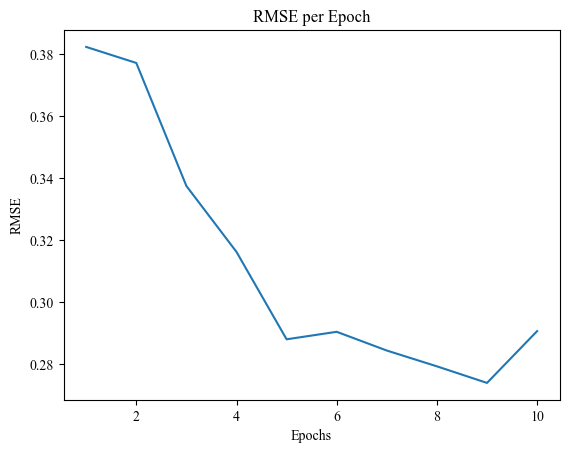

| 33        | -3.019    | 0.0       | 50.0      | 0.1       | 10.0      | 84.95     | 178.0     | 43.57     |
Epoch 1/14, RMSE: 0.4298
Epoch 2/14, RMSE: 0.4081
Epoch 3/14, RMSE: 0.3602
Epoch 4/14, RMSE: 0.3478
Epoch 5/14, RMSE: 0.3068
Epoch 6/14, RMSE: 0.3013
Epoch 7/14, RMSE: 0.2769
Epoch 8/14, RMSE: 0.2891
Epoch 9/14, RMSE: 0.2944
Epoch 10/14, RMSE: 0.2985
Epoch 11/14, RMSE: 0.2884
Epoch 12/14, RMSE: 0.2740
Epoch 13/14, RMSE: 0.2692
Epoch 14/14, RMSE: 0.2753


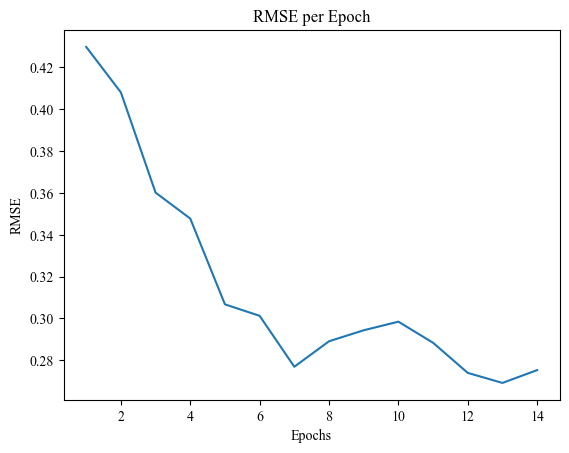

| 34        | -2.968    | 1.007     | 46.23     | 0.1026    | 14.38     | 209.1     | 204.0     | 69.44     |
Epoch 1/13, RMSE: 0.4237
Epoch 2/13, RMSE: 0.3967
Epoch 3/13, RMSE: 0.3855
Epoch 4/13, RMSE: 0.3228
Epoch 5/13, RMSE: 0.3498
Epoch 6/13, RMSE: 0.3173
Epoch 7/13, RMSE: 0.3789
Epoch 8/13, RMSE: 0.2831
Epoch 9/13, RMSE: 0.2849
Epoch 10/13, RMSE: 0.2656
Epoch 11/13, RMSE: 0.2710
Epoch 12/13, RMSE: 0.2685
Epoch 13/13, RMSE: 0.3020


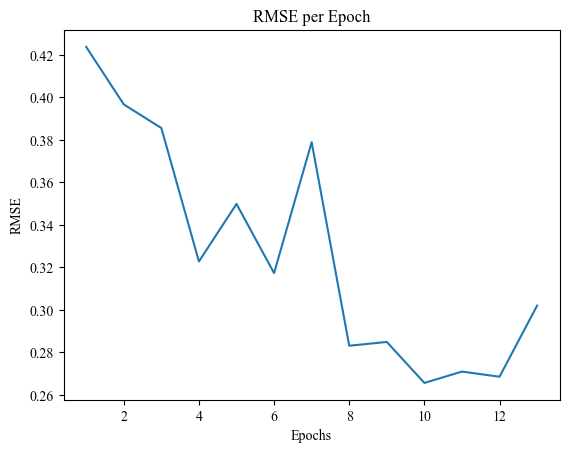

| 35        | -3.102    | 0.3783    | 47.82     | 0.3768    | 13.97     | 174.4     | 196.8     | 108.0     |
Epoch 1/13, RMSE: 0.4420
Epoch 2/13, RMSE: 0.3907
Epoch 3/13, RMSE: 0.4268
Epoch 4/13, RMSE: 0.3222
Epoch 5/13, RMSE: 0.3175
Epoch 6/13, RMSE: 0.2961
Epoch 7/13, RMSE: 0.2903
Epoch 8/13, RMSE: 0.2798
Epoch 9/13, RMSE: 0.2911
Epoch 10/13, RMSE: 0.2876
Epoch 11/13, RMSE: 0.2826
Epoch 12/13, RMSE: 0.2809
Epoch 13/13, RMSE: 0.2884


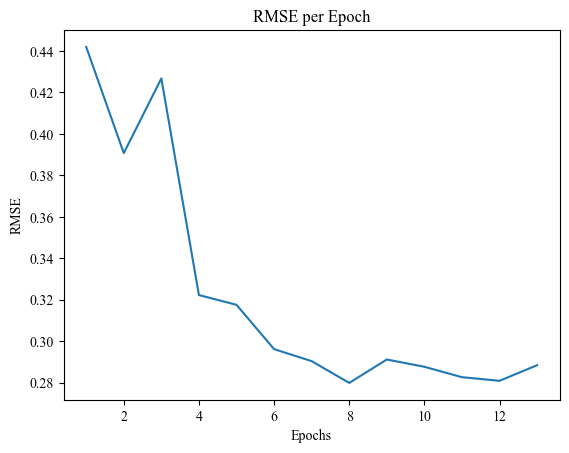

| 36        | -2.97     | 0.2851    | 48.23     | 0.3751    | 13.04     | 215.9     | 224.1     | 127.9     |
Epoch 1/28, RMSE: 0.4093
Epoch 2/28, RMSE: 0.4240
Epoch 3/28, RMSE: 0.3512
Epoch 4/28, RMSE: 0.3447
Epoch 5/28, RMSE: 0.3056
Epoch 6/28, RMSE: 0.3376
Epoch 7/28, RMSE: 0.3014
Epoch 8/28, RMSE: 0.3027
Epoch 9/28, RMSE: 0.2881
Epoch 10/28, RMSE: 0.2742
Epoch 11/28, RMSE: 0.2834
Epoch 12/28, RMSE: 0.2671
Epoch 13/28, RMSE: 0.2665
Epoch 14/28, RMSE: 0.2893
Epoch 15/28, RMSE: 0.2910
Epoch 16/28, RMSE: 0.2995
Epoch 17/28, RMSE: 0.2888
Epoch 18/28, RMSE: 0.2786
Epoch 19/28, RMSE: 0.3119
Epoch 20/28, RMSE: 0.2852
Epoch 21/28, RMSE: 0.2904
Epoch 22/28, RMSE: 0.2763
Epoch 23/28, RMSE: 0.3333
Early stopping at epoch 23


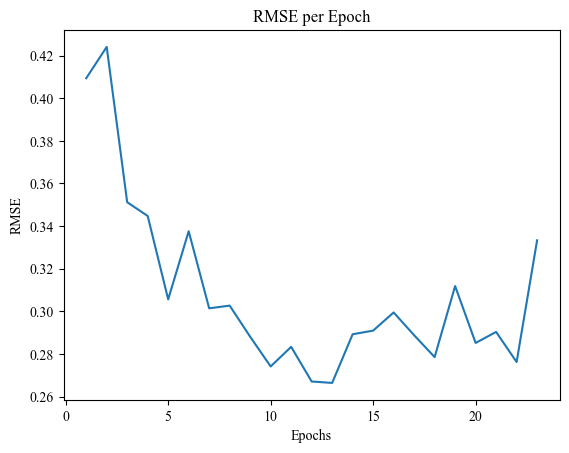

| 37        | -3.514    | 0.3533    | 48.53     | 0.3379    | 28.21     | 124.0     | 255.9     | 45.05     |
Epoch 1/11, RMSE: 0.4462
Epoch 2/11, RMSE: 0.4046
Epoch 3/11, RMSE: 0.3759
Epoch 4/11, RMSE: 0.3080
Epoch 5/11, RMSE: 0.3261
Epoch 6/11, RMSE: 0.3355
Epoch 7/11, RMSE: 0.3067
Epoch 8/11, RMSE: 0.2871
Epoch 9/11, RMSE: 0.3399
Epoch 10/11, RMSE: 0.3275
Epoch 11/11, RMSE: 0.2964


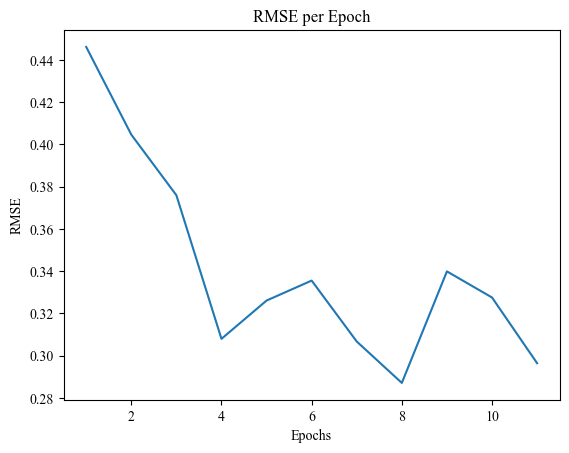

| 38        | -3.059    | 0.1373    | 46.84     | 0.1566    | 11.15     | 236.4     | 234.5     | 90.66     |
Epoch 1/45, RMSE: 0.4145
Epoch 2/45, RMSE: 0.4235
Epoch 3/45, RMSE: 0.3640
Epoch 4/45, RMSE: 0.3439
Epoch 5/45, RMSE: 0.3329
Epoch 6/45, RMSE: 0.3151
Epoch 7/45, RMSE: 0.3134
Epoch 8/45, RMSE: 0.3068
Epoch 9/45, RMSE: 0.2907
Epoch 10/45, RMSE: 0.3009
Epoch 11/45, RMSE: 0.2833
Epoch 12/45, RMSE: 0.2923
Epoch 13/45, RMSE: 0.2642
Epoch 14/45, RMSE: 0.2726
Epoch 15/45, RMSE: 0.2775
Epoch 16/45, RMSE: 0.3029
Epoch 17/45, RMSE: 0.2810
Epoch 18/45, RMSE: 0.2655
Epoch 19/45, RMSE: 0.2610
Epoch 20/45, RMSE: 0.2542
Epoch 21/45, RMSE: 0.2930
Epoch 22/45, RMSE: 0.2902
Epoch 23/45, RMSE: 0.2683
Epoch 24/45, RMSE: 0.2908
Epoch 25/45, RMSE: 0.3045
Epoch 26/45, RMSE: 0.2821
Epoch 27/45, RMSE: 0.2797
Epoch 28/45, RMSE: 0.2865
Epoch 29/45, RMSE: 0.2732
Epoch 30/45, RMSE: 0.2636
Early stopping at epoch 30


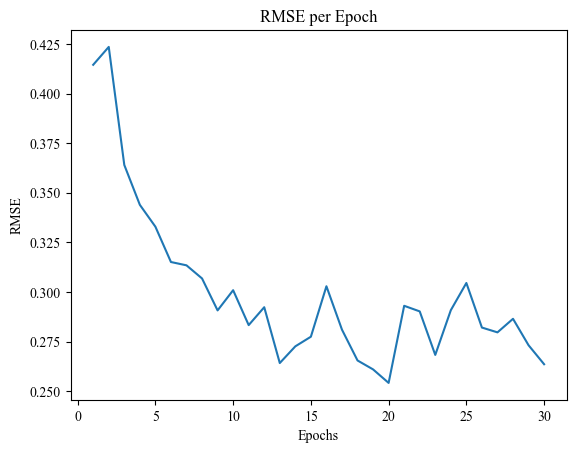

| 39        | -2.691    | 0.7887    | 46.72     | 0.1576    | 45.58     | 144.9     | 185.8     | 126.1     |
Epoch 1/49, RMSE: 0.4577
Epoch 2/49, RMSE: 0.3849
Epoch 3/49, RMSE: 0.3690
Epoch 4/49, RMSE: 0.3572
Epoch 5/49, RMSE: 0.3467
Epoch 6/49, RMSE: 0.3072
Epoch 7/49, RMSE: 0.2894
Epoch 8/49, RMSE: 0.2760
Epoch 9/49, RMSE: 0.2814
Epoch 10/49, RMSE: 0.3123
Epoch 11/49, RMSE: 0.3177
Epoch 12/49, RMSE: 0.3481
Epoch 13/49, RMSE: 0.3429
Epoch 14/49, RMSE: 0.4169
Epoch 15/49, RMSE: 0.4032
Epoch 16/49, RMSE: 0.3723
Epoch 17/49, RMSE: 0.3798
Epoch 18/49, RMSE: 0.3748
Early stopping at epoch 18


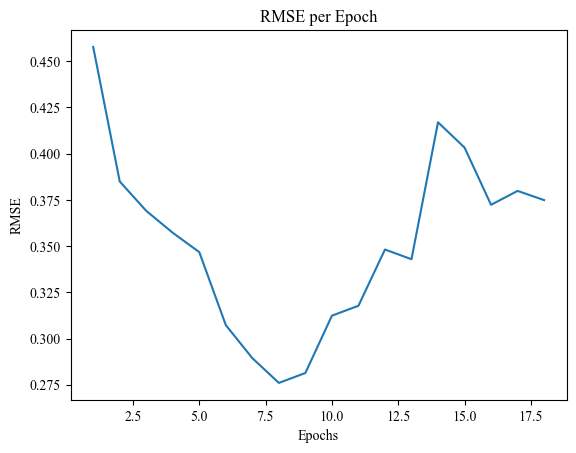

| 40        | -3.7      | 0.1088    | 24.5      | 0.193     | 49.06     | 124.5     | 187.4     | 114.9     |
Mejores hiperparámetros: Epochs=41, Batch size=42, Dropout=0.10503016778609382, Hidden Dims=[255, 159, 36], Activation=ReLU()
Epoch 1/41, RMSE: 0.3751
Epoch 2/41, RMSE: 0.3461
Epoch 3/41, RMSE: 0.3709
Epoch 4/41, RMSE: 0.3359
Epoch 5/41, RMSE: 0.3491
Epoch 6/41, RMSE: 0.3195
Epoch 7/41, RMSE: 0.3485
Epoch 8/41, RMSE: 0.3499
Epoch 9/41, RMSE: 0.3295
Epoch 10/41, RMSE: 0.3095
Epoch 11/41, RMSE: 0.3083
Epoch 12/41, RMSE: 0.2980
Epoch 13/41, RMSE: 0.2817
Epoch 14/41, RMSE: 0.2735
Epoch 15/41, RMSE: 0.2840
Epoch 16/41, RMSE: 0.2705
Epoch 17/41, RMSE: 0.2807
Epoch 18/41, RMSE: 0.2694
Epoch 19/41, RMSE: 0.2721
Epoch 20/41, RMSE: 0.2583
Epoch 21/41, RMSE: 0.2487
Epoch 22/41, RMSE: 0.2587
Epoch 23/41, RMSE: 0.2629
Epoch 24/41, RMSE: 0.2663
Epoch 25/41, RMSE: 0.2594
Epoch 26/41, RMSE: 0.2531
Epoch 27/41, RMSE: 0.2548
Epoch 28/41, RMSE: 0.2673
Epoch 29/41, RMSE: 0.2702
Epoch 30/41, RMSE: 

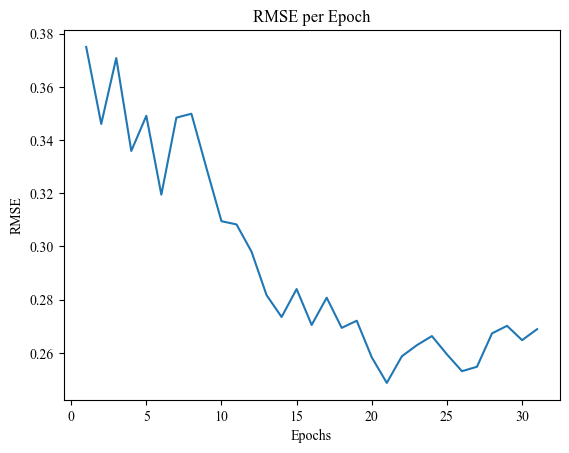

In [78]:
# Definir la clase del modelo ANN con más capas y Dropout
class ANNModel(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout_prob=0.5, activation_fn=nn.ReLU()):
        super(ANNModel, self).__init__()
        self.hidden_layers = nn.ModuleList()
        self.dropout = nn.Dropout(dropout_prob)
        self.activation_fn = activation_fn
        
        # Primera capa
        self.hidden_layers.append(nn.Linear(input_dim, hidden_dims[0]))
        
        # Capas ocultas intermedias
        for i in range(1, len(hidden_dims)):
            self.hidden_layers.append(nn.Linear(hidden_dims[i-1], hidden_dims[i]))
        
        # Capa de salida
        self.output_layer = nn.Linear(hidden_dims[-1], 1)

    def forward(self, x):
        for layer in self.hidden_layers:
            x = self.activation_fn(layer(x))
            x = self.dropout(x)
        x = self.output_layer(x)
        return x

# Definir una clase para convertir ANNModel a un estimador compatible con scikit-learn
class SklearnWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout_prob=0.5, activation_fn=nn.ReLU(), 
                 epochs=100, batch_size=32, learning_rate=0.001):
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.dropout_prob = dropout_prob
        self.activation_fn = activation_fn
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.model = ANNModel(input_dim, hidden_dims, dropout_prob, activation_fn)
        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=50, gamma=0.1)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()

    def fit(self, X, y):
        # Estandarizar los datos
        X = self.scaler_X.fit_transform(X)
        if isinstance(y, pd.Series):
            y = y.to_numpy()  # Convertir a numpy array si es necesario
        y = y.reshape(-1, 1)  # Asegurarse de que 'y' tenga la forma correcta
        y = self.scaler_y.fit_transform(y).flatten()

        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        y_tensor = torch.tensor(y, dtype=torch.float32).to(self.device)
        
        self.model.train()
        rmse_list = []
        best_rmse = float('inf')
        patience = 10
        patience_counter = 0

        for epoch in range(self.epochs):
            for i in range(0, len(X_tensor), self.batch_size):
                X_batch = X_tensor[i:i + self.batch_size]
                y_batch = y_tensor[i:i + self.batch_size]

                self.optimizer.zero_grad()
                outputs = self.model(X_batch).squeeze()
                loss = self.criterion(outputs, y_batch)
                loss.backward()
                self.optimizer.step()

            self.scheduler.step()

            # Evaluar el modelo después de cada epoch
            self.model.eval()
            with torch.no_grad():
                y_pred = self.model(X_tensor).squeeze().cpu().numpy()
                rmse = np.sqrt(mean_squared_error(y_tensor.cpu().numpy(), y_pred))
                rmse_list.append(rmse)
                print(f'Epoch {epoch+1}/{self.epochs}, RMSE: {rmse:.4f}')
                
                # Early stopping
                if rmse < best_rmse:
                    best_rmse = rmse
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= patience:
                        print(f'Early stopping at epoch {epoch+1}')
                        break

            self.model.train()
        
        # Graficar el RMSE por epoch
        plt.plot(range(1, len(rmse_list) + 1), rmse_list)
        plt.xlabel('Epochs')
        plt.ylabel('RMSE')
        plt.title('RMSE per Epoch')
        plt.show()
        
        return self

    def predict(self, X):
        X = self.scaler_X.transform(X)
        
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        self.model.eval()
        with torch.no_grad():
            y_pred = self.model(X_tensor).squeeze().cpu().numpy()
        y_pred = self.scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
        return y_pred

# Función auxiliar para decodificar la función de activación
def get_activation_function(name):
    if name == 0:
        return nn.ReLU()
    elif name == 1:
        return nn.Tanh()
    elif name == 2:
        return nn.LeakyReLU()
    else:
        return nn.ReLU()  # Default

# Guardar el modelo entrenado
def save_model(model, filename):
    joblib.dump(model, filename)

# Cargar el modelo entrenado
def load_model(filename):
    return joblib.load(filename)

# Definir la función de optimización
def train_evaluate_ANN(epochs, batch_size, dropout_prob, hidden_dim1, hidden_dim2, hidden_dim3, activation_fn):
    input_dim = X_train_grecipe.shape[1]
    hidden_dims = [int(hidden_dim1), int(hidden_dim2), int(hidden_dim3)]
    activation = get_activation_function(activation_fn)

    ann_wrapper = SklearnWrapper(input_dim=input_dim, hidden_dims=hidden_dims, dropout_prob=dropout_prob, 
                                 activation_fn=activation, epochs=int(epochs), batch_size=int(batch_size))
    ann_wrapper.fit(X_train_grecipe, y_train_grecipe)
    
    y_pred = ann_wrapper.predict(X_test_grecipe)
    mse = mean_squared_error(y_test_grecipe, y_pred)
    rmse = np.sqrt(mse)
    return -rmse  # Negamos el RMSE porque BayesianOptimization maximiza la función objetivo

# Rango de hiperparámetros para la optimización bayesiana
pbounds = {
    'epochs': (10, 50),
    'batch_size': (10, 50),
    'dropout_prob': (0.1, 0.5),
    'hidden_dim1': (64, 256),
    'hidden_dim2': (64, 256),
    'hidden_dim3': (32, 128),
    'activation_fn': (0, 2)  # 0: ReLU, 1: Tanh, 2: LeakyReLU
}

# Realizar la optimización bayesiana
optimizer = BayesianOptimization(
    f=train_evaluate_ANN,
    pbounds=pbounds,
    random_state=42
)

optimizer.maximize(init_points=10, n_iter=30)

# Obtener los mejores hiperparámetros
best_params = optimizer.max['params']
best_epochs = int(best_params['epochs'])
best_batch_size = int(best_params['batch_size'])
best_dropout_prob = best_params['dropout_prob']
best_hidden_dims = [int(best_params['hidden_dim1']), int(best_params['hidden_dim2']), int(best_params['hidden_dim3'])]
best_activation = get_activation_function(best_params['activation_fn'])

print(f'Mejores hiperparámetros: Epochs={best_epochs}, Batch size={best_batch_size}, Dropout={best_dropout_prob}, Hidden Dims={best_hidden_dims}, Activation={best_activation}')

input_dim = X_train_grecipe.shape[1]

# Entrenar y evaluar el modelo final con los mejores hiperparámetros
ann_wrapper = SklearnWrapper(input_dim=input_dim, hidden_dims=best_hidden_dims, dropout_prob=best_dropout_prob, 
                             activation_fn=best_activation, epochs=best_epochs, batch_size=best_batch_size)
ann_wrapper.fit(X_train_grecipe, y_train_grecipe)

# Guardar el modelo entrenado
save_model(ann_wrapper, 'ann_model_grecipe1.pkl')

In [79]:
# Cargar el modelo entrenado
loaded_model_ann_grecipe = load_model('ann_model_grecipe1.pkl')

y_pred_ann_grecipe = loaded_model_ann_grecipe.predict(X_test_grecipe)
    
# Calcular las métricas
mse_ann_grecipe = mean_squared_error(y_test_grecipe, y_pred_ann_grecipe)
rmse_ann_grecipe = np.sqrt(mse_ann_grecipe)
mae_ann_grecipe = mean_absolute_error(y_test_grecipe, y_pred_ann_grecipe)
r2_ann_grecipe = r2_score(y_test_grecipe, y_pred_ann_grecipe)
    
# Imprimier las métricas
print(f"Mean Squared Error (MSE): {mse_ann_grecipe:.5f}")
print(f"Root Mean Squared Error (RMSE): {rmse_ann_grecipe:.5f}")
print(f"Mean Absolute Error (MAE): {mae_ann_grecipe:.5f}")
print(f"R-squared (R^2): {r2_ann_grecipe:.5f}")

Mean Squared Error (MSE): 7.69415
Root Mean Squared Error (RMSE): 2.77383
Mean Absolute Error (MAE): 2.02794
R-squared (R^2): 0.92935


In [80]:
# Obtener los mejores hiperparámetros
best_params = optimizer.max['params']
best_epochs = int(best_params['epochs'])
best_batch_size = int(best_params['batch_size'])
best_dropout_prob = best_params['dropout_prob']
best_hidden_dims = [int(best_params['hidden_dim1']), int(best_params['hidden_dim2']), int(best_params['hidden_dim3'])]
best_activation = get_activation_function(best_params['activation_fn'])

# Imprimir los mejores hiperparámetros
print(f'Mejores hiperparámetros:')
print(f'  Epochs: {best_epochs}')
print(f'  Batch size: {best_batch_size}')
print(f'  Dropout probability: {best_dropout_prob}')
print(f'  Hidden layer sizes: {best_hidden_dims}')
print(f'  Activation function: {best_activation}')

Mejores hiperparámetros:
  Epochs: 41
  Batch size: 42
  Dropout probability: 0.10503016778609382
  Hidden layer sizes: [255, 159, 36]
  Activation function: ReLU()


In [82]:
# Guardar las predicciones 
# Convertir las predicciones a un DataFrame de pandas
pred_ann_grecipe = pd.DataFrame(y_pred_ann_grecipe, columns=['pred_ann_grecipe'])

# Guardar el DataFrame como un archivo CSV
pred_ann_grecipe.to_csv('y_pred_ann_grecipe.csv', index=False)

### Modelo XGBoost 

In [85]:
# Definición de la función de validación cruzada
def xgb_cv(n_estimators, max_depth, learning_rate, subsample, colsample_bytree, gamma, min_child_weight):
    model = XGBRegressor(
        n_estimators=int(n_estimators), 
        max_depth=int(max_depth), 
        learning_rate=learning_rate, 
        subsample=subsample, 
        colsample_bytree=colsample_bytree, 
        gamma=gamma, 
        min_child_weight=min_child_weight, 
        objective='reg:squarederror',
        n_jobs=-1
    )
    model.fit(X_train_grecipe, y_train_grecipe)
    y_pred = model.predict(X_test_grecipe)
    return -mean_squared_error(y_test_grecipe, y_pred)

# Optimización bayesiana para XGBoost
xgb_optimizer = BayesianOptimization(
    f=xgb_cv,
    pbounds={
        'n_estimators': (10, 200),
        'max_depth': (1, 20),
        'learning_rate': (0.01, 0.3),
        'subsample': (0.5, 1.0),
        'colsample_bytree': (0.5, 1.0),
        'gamma': (0, 5),
        'min_child_weight': (1, 10)
    },
    random_state=42
)

xgb_optimizer.maximize(init_points=10, n_iter=30)

# Obtener los mejores valores de hiperparámetros para XGBoost
best_n_estimators = int(xgb_optimizer.max['params']['n_estimators'])
best_max_depth = int(xgb_optimizer.max['params']['max_depth'])
best_learning_rate = xgb_optimizer.max['params']['learning_rate']
best_subsample = xgb_optimizer.max['params']['subsample']
best_colsample_bytree = xgb_optimizer.max['params']['colsample_bytree']
best_gamma = xgb_optimizer.max['params']['gamma']
best_min_child_weight = xgb_optimizer.max['params']['min_child_weight']

# Entrenar el modelo XGBoost con los mejores valores de hiperparámetros
xgb_model_grecipe = XGBRegressor(
    n_estimators=best_n_estimators, 
    max_depth=best_max_depth, 
    learning_rate=best_learning_rate, 
    subsample=best_subsample, 
    colsample_bytree=best_colsample_bytree, 
    gamma=best_gamma, 
    min_child_weight=best_min_child_weight, 
    objective='reg:squarederror',
    n_jobs=-1
)
xgb_model_grecipe.fit(X_train_grecipe, y_train_grecipe)


|   iter    |  target   | colsam... |   gamma   | learni... | max_depth | min_ch... | n_esti... | subsample |
-------------------------------------------------------------------------------------------------------------
| 1         | -6.722    | 0.6873    | 4.754     | 0.2223    | 12.37     | 2.404     | 39.64     | 0.529     |
| 2         | -11.73    | 0.9331    | 3.006     | 0.2153    | 1.391     | 9.729     | 168.2     | 0.6062    |
| 3         | -7.265    | 0.5909    | 0.917     | 0.09823   | 10.97     | 4.888     | 65.33     | 0.8059    |
| 4         | -7.26     | 0.5697    | 1.461     | 0.1162    | 9.665     | 8.067     | 47.94     | 0.7571    |
| 5         | -6.572    | 0.7962    | 0.2323    | 0.1862    | 4.24      | 1.585     | 190.3     | 0.9828    |
| 6         | -16.11    | 0.9042    | 1.523     | 0.03832   | 14.0      | 4.961     | 33.19     | 0.7476    |
| 7         | -7.982    | 0.5172    | 4.547     | 0.08505   | 13.59     | 3.805     | 108.8     | 0.7734    |
| 8       

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=np.float64(0.8090647494416048), device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=np.float64(0.5020240691828232), grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=np.float64(0.06745457968135488), max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=np.float64(3.111403959136541), missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=188,
             n_jobs=-1, num_parallel_tree=None, ...)

In [86]:
print(f"n_estimators: {best_n_estimators}")
print(f"max_depth: {best_max_depth}")
print(f"learning_rate: {best_learning_rate}")
print(f"subsample: {best_subsample}")
print(f"colsample_bytree: {best_colsample_bytree}")
print(f"gamma: {best_gamma}")
print(f"min_child_weight: {best_min_child_weight}")

n_estimators: 188
max_depth: 6
learning_rate: 0.06745457968135488
subsample: 0.9057861548211675
colsample_bytree: 0.8090647494416048
gamma: 0.5020240691828232
min_child_weight: 3.111403959136541


In [87]:
# Guardar el modelo entrenado
joblib.dump(xgb_model_grecipe, 'xgb_model_grecipe.pkl')

# Cargar el modelo entrenado
loaded_model_xgb_grecipe = joblib.load('xgb_model_grecipe.pkl')
loaded_model_xgb_grecipe

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=np.float64(0.8090647494416048), device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=np.float64(0.5020240691828232), grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=np.float64(0.06745457968135488), max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=np.float64(3.111403959136541), missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=188,
             n_jobs=-1, num_parallel_tree=None, ...)

In [88]:
# Evaluar el modelo
y_pred_xgb_grecipe = loaded_model_xgb_grecipe.predict(X_test_grecipe)
xgb_mse_grecipe = mean_squared_error(y_test_grecipe, y_pred_xgb_grecipe)

# Calcular las métricas
mse_xgb_grecipe = mean_squared_error(y_test_grecipe, y_pred_xgb_grecipe)
rmse_xgb_grecipe = np.sqrt(mse_xgb_grecipe)
mae_xgb_grecipe = mean_absolute_error(y_test_grecipe, y_pred_xgb_grecipe)
r2_xgb_grecipe = r2_score(y_test_grecipe, y_pred_xgb_grecipe)

# Imprimier las métricas
print(f"Mean Squared Error (MSE): {mse_xgb_grecipe:.5f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb_grecipe:.5f}")
print(f"Mean Absolute Error (MAE): {mae_xgb_grecipe:.5f}")
print(f"R-squared (R^2): {r2_xgb_grecipe:.5f}")

Mean Squared Error (MSE): 5.57561
Root Mean Squared Error (RMSE): 2.36127
Mean Absolute Error (MAE): 1.56097
R-squared (R^2): 0.94880


In [89]:
# Guardamos las predicciones que se necesitarán más adelante
# Convertir las predicciones a un DataFrame de pandas
y_pred_xgb_grecipe = pd.DataFrame(y_pred_xgb_grecipe, columns=['pred_xgb_grecipe'])

# Guardar el DataFrame como un archivo CSV
y_pred_xgb_grecipe.to_csv('y_pred_xgb_grecipe.csv', index=False)

### Modelo KNN 

In [96]:
# Normalizar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_grecipe)
X_test_scaled = scaler.transform(X_test_grecipe)

# Reducir dimensionalidad con PCA
pca = PCA(n_components=0.95)  # Retener 95% de la varianza
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Definir el modelo KNN
knn = KNeighborsRegressor()

# Definir los hiperparámetros a optimizar
param_grid = {
    'n_neighbors': (1, 30),
    'leaf_size': (10, 50),
    'p': (1, 2),  # 1 para Manhattan, 2 para Euclídea
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
}

# Configurar la búsqueda bayesiana
opt = BayesSearchCV(
    knn,
    param_grid,
    n_iter=50,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Ejecutar la búsqueda bayesiana
opt.fit(X_train_pca, y_train_grecipe)

# Imprimir los mejores hiperparámetros encontrados
print("Best Hyperparameters: ", opt.best_params_)

# Entrenar el modelo con los mejores hiperparámetros
best_knn_grecipe = opt.best_estimator_
best_knn_grecipe.fit(X_train_pca, y_train_grecipe)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

KNeighborsRegressor(algorithm='kd_tree', leaf_size=10, metric='euclidean',
                    n_neighbors=30)

In [97]:
# Imprimir los mejores hiperparámetros encontrados uno por uno
best_params = opt.best_params_
print("Best Hyperparameters:")
for param, value in best_params.items():
    print(f"{param}: {value}")

Best Hyperparameters:
algorithm: kd_tree
leaf_size: 10
metric: euclidean
n_neighbors: 30
p: 2
weights: uniform


In [98]:
# Guardar el modelo entrenado
joblib.dump(best_knn_grecipe, 'knn_model_grecipe.pkl')

# Cargar el modelo entrenado
loaded_model_knn_grecipe = joblib.load('knn_model_grecipe.pkl')
loaded_model_knn_grecipe

KNeighborsRegressor(algorithm='kd_tree', leaf_size=10, metric='euclidean',
                    n_neighbors=30)

In [99]:
# Predecir y evaluar el modelo
y_pred_knn_grecipe = loaded_model_knn_grecipe.predict(X_test_pca)

# Calcular las métricas
mae_knn_grecipe = mean_absolute_error(y_test_grecipe, y_pred_knn_grecipe)
mse_knn_grecipe = mean_squared_error(y_test_grecipe, y_pred_knn_grecipe)
rmse_knn_grecipe = np.sqrt(mse_knn_grecipe)
r2_knn_grecipe = r2_score(y_test_grecipe, y_pred_knn_grecipe)

# Imprimir las métricas
print(f"Mean Squared Error (MSE): {mse_knn_grecipe:.5f}")
print(f"Root Mean Squared Error (RMSE): {rmse_knn_grecipe:.5f}")
print(f"Mean Absolute Error (MAE): {mae_knn_grecipe:.5f}")
print(f"R-squared (R^2): {r2_knn_grecipe:.5f}")

Mean Squared Error (MSE): 6.43625
Root Mean Squared Error (RMSE): 2.53698
Mean Absolute Error (MAE): 1.64312
R-squared (R^2): 0.94090


In [101]:
# Guardar las predicciones 
# Convertir las predicciones a un DataFrame de pandas
pred_knn_grecipe = pd.DataFrame(y_pred_knn_grecipe, columns=['pred_knn_grecipe'])

# Guardar el DataFrame como un archivo CSV
pred_knn_grecipe.to_csv('y_pred_knn_grecipe.csv', index=False)

### Ensamble Heterogéneo con 4 modelos

In [109]:
ensemble_model_grecipe = VotingRegressor(estimators=[
    ('lasso', loaded_model_lasso_grecipe),
    ('rf', loaded_model_rf_grecipe),
    ('xgb', loaded_model_xgb_grecipe),
    ('knn', loaded_model_knn_grecipe)
])

# Entrenar el modelo ensemble
ensemble_model_grecipe.fit(X_train_grecipe, y_train_grecipe)

VotingRegressor(estimators=[('lasso',
                             Pipeline(steps=[('scaler', StandardScaler()),
                                             ('lasso',
                                              Lasso(alpha=np.float64(0.08621899631748546),
                                                    max_iter=347,
                                                    tol=np.float64(0.07582827751874303)))])),
                            ('rf',
                             RandomForestRegressor(bootstrap=np.False_,
                                                   max_depth=15,
                                                   max_features=np.float64(0.2797064039425238),
                                                   min_samples_leaf=10,
                                                   min_samples_split=12,
                                                   n_estimators=18)...
                                          max_bin=None, max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=6,
                                          max_leaves=None,
                                          min_child_weight=np.float64(3.111403959136541),
                                          missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None, n_estimators=188,
                                          n_jobs=-1, num_parallel_tree=None, ...)),
                            ('knn',
                             KNeighborsRegressor(algorithm='kd_tree',
                                                 leaf_size=10,
                                                 metric='euclidean',
                                                 n_neighbors=30))])

In [110]:
# Guardar el modelo entrenado
joblib.dump(ensemble_model_grecipe, 'ensemble_model_grecipe.pkl')

# Cargar el modelo entrenado
loaded_model_esemble_grecipe = joblib.load('ensemble_model_grecipe.pkl')

In [111]:
# Evaluar el modelo ensemble
y_pred_ensamble_grecipe = loaded_model_esemble_grecipe.predict(X_test_grecipe)

In [112]:
# Méttricas
mae_ensamble_grecipe = mean_absolute_error(y_test_grecipe, y_pred_ensamble_grecipe) # Calcular el Error Medio Absoluto (MAE)
mse_ensamble_grecipe = mean_squared_error(y_test_grecipe, y_pred_ensamble_grecipe) # Calcular el Error Cuadrático Medio (MSE)
rmse_ensamble_grecipe = np.sqrt(mse_ensamble_grecipe) # Calcular la Raíz del Error Cuadrático Medio (RMSE)
r2_ensamble_grecipe = r2_score(y_test_grecipe, y_pred_ensamble_grecipe) # Calcular el Coeficiente de Determinación (R^2)

print(f"Error Cuadrático Medio (MSE): {mse_ensamble_grecipe:.5f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_ensamble_grecipe:.5f}")
print(f"Error Medio Absoluto (MAE): {mae_ensamble_grecipe:.5f}")
print(f"Coeficiente de Determinación (R^2): {r2_ensamble_grecipe:.5f}")

Error Cuadrático Medio (MSE): 10.86661
Raíz del Error Cuadrático Medio (RMSE): 3.29645
Error Medio Absoluto (MAE): 2.40619
Coeficiente de Determinación (R^2): 0.90022


In [113]:
# Guardar las predicciones 
# Convertir las predicciones a un DataFrame de pandas
pred_ensamble_grecipe = pd.DataFrame(y_pred_ensamble_grecipe, columns=['pred_ensamble_grecipe'])

# Guardar el DataFrame como un archivo CSV
pred_ensamble_grecipe.to_csv('y_pred_ensamble_grecipe.csv', index=False)

Los modelos con mejor rendimiento fueron Random forest y XGBoost. 

### Ensamble Heterogéneo con los modelos seleccionados

In [115]:
ensemble_model_grecipe_select = VotingRegressor(estimators=[
    ('rf', loaded_model_rf_grecipe),
    ('xgb', loaded_model_xgb_grecipe),
    
])

# Entrenar el modelo ensemble
ensemble_model_grecipe_select.fit(X_train_grecipe, y_train_grecipe)

VotingRegressor(estimators=[('rf',
                             RandomForestRegressor(bootstrap=np.False_,
                                                   max_depth=15,
                                                   max_features=np.float64(0.2797064039425238),
                                                   min_samples_leaf=10,
                                                   min_samples_split=12,
                                                   n_estimators=18)),
                            ('xgb',
                             XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=np.float64(0.8090647494416048),
                                          d...
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=np.float64(0.06745457968135488),
                                          max_bin=None, max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=6,
                                          max_leaves=None,
                                          min_child_weight=np.float64(3.111403959136541),
                                          missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None, n_estimators=188,
                                          n_jobs=-1, num_parallel_tree=None, ...))])

In [116]:
# Guardar el modelo entrenado
joblib.dump(ensemble_model_grecipe_select, 'ensemble_model_grecipe_select.pkl')

# Cargar el modelo entrenado
loaded_model_esemble_grecipe = joblib.load('ensemble_model_grecipe_select.pkl')

In [117]:
# Evaluar el modelo ensemble
y_pred_ensamble_grecipe_select = ensemble_model_grecipe_select.predict(X_test_grecipe)

In [118]:
# Méttricas
mae_ensamble_grecipe_select = mean_absolute_error(y_test_grecipe, y_pred_ensamble_grecipe_select) # Calcular el Error Medio Absoluto (MAE)
mse_ensamble_grecipe_select = mean_squared_error(y_test_grecipe, y_pred_ensamble_grecipe_select) # Calcular el Error Cuadrático Medio (MSE)
rmse_ensamble_grecipe_select = np.sqrt(mse_ensamble_grecipe_select) # Calcular la Raíz del Error Cuadrático Medio (RMSE)
r2_ensamble_grecipe_select = r2_score(y_test_grecipe, y_pred_ensamble_grecipe_select) # Calcular el Coeficiente de Determinación (R^2)

print(f"Error Cuadrático Medio (MSE): {mse_ensamble_grecipe_select:.5f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_ensamble_grecipe_select:.5f}")
print(f"Error Medio Absoluto (MAE): {mae_ensamble_grecipe_select:.5f}")
print(f"Coeficiente de Determinación (R^2): {r2_ensamble_grecipe_select:.5f}")

Error Cuadrático Medio (MSE): 5.49356
Raíz del Error Cuadrático Medio (RMSE): 2.34383
Error Medio Absoluto (MAE): 1.52308
Coeficiente de Determinación (R^2): 0.94955


In [119]:
# Guardar las predicciones 
# Convertir las predicciones a un DataFrame de pandas
pred_ensamble_select_grecipe = pd.DataFrame(y_pred_ensamble_grecipe_select, columns=['pred_ensamble_select_grecipe'])

# Guardar el DataFrame como un archivo CSV
pred_ensamble_select_grecipe.to_csv('y_pred_ensamble_grecipe_select.csv', index=False)

### Modelos y métricas con ensambles

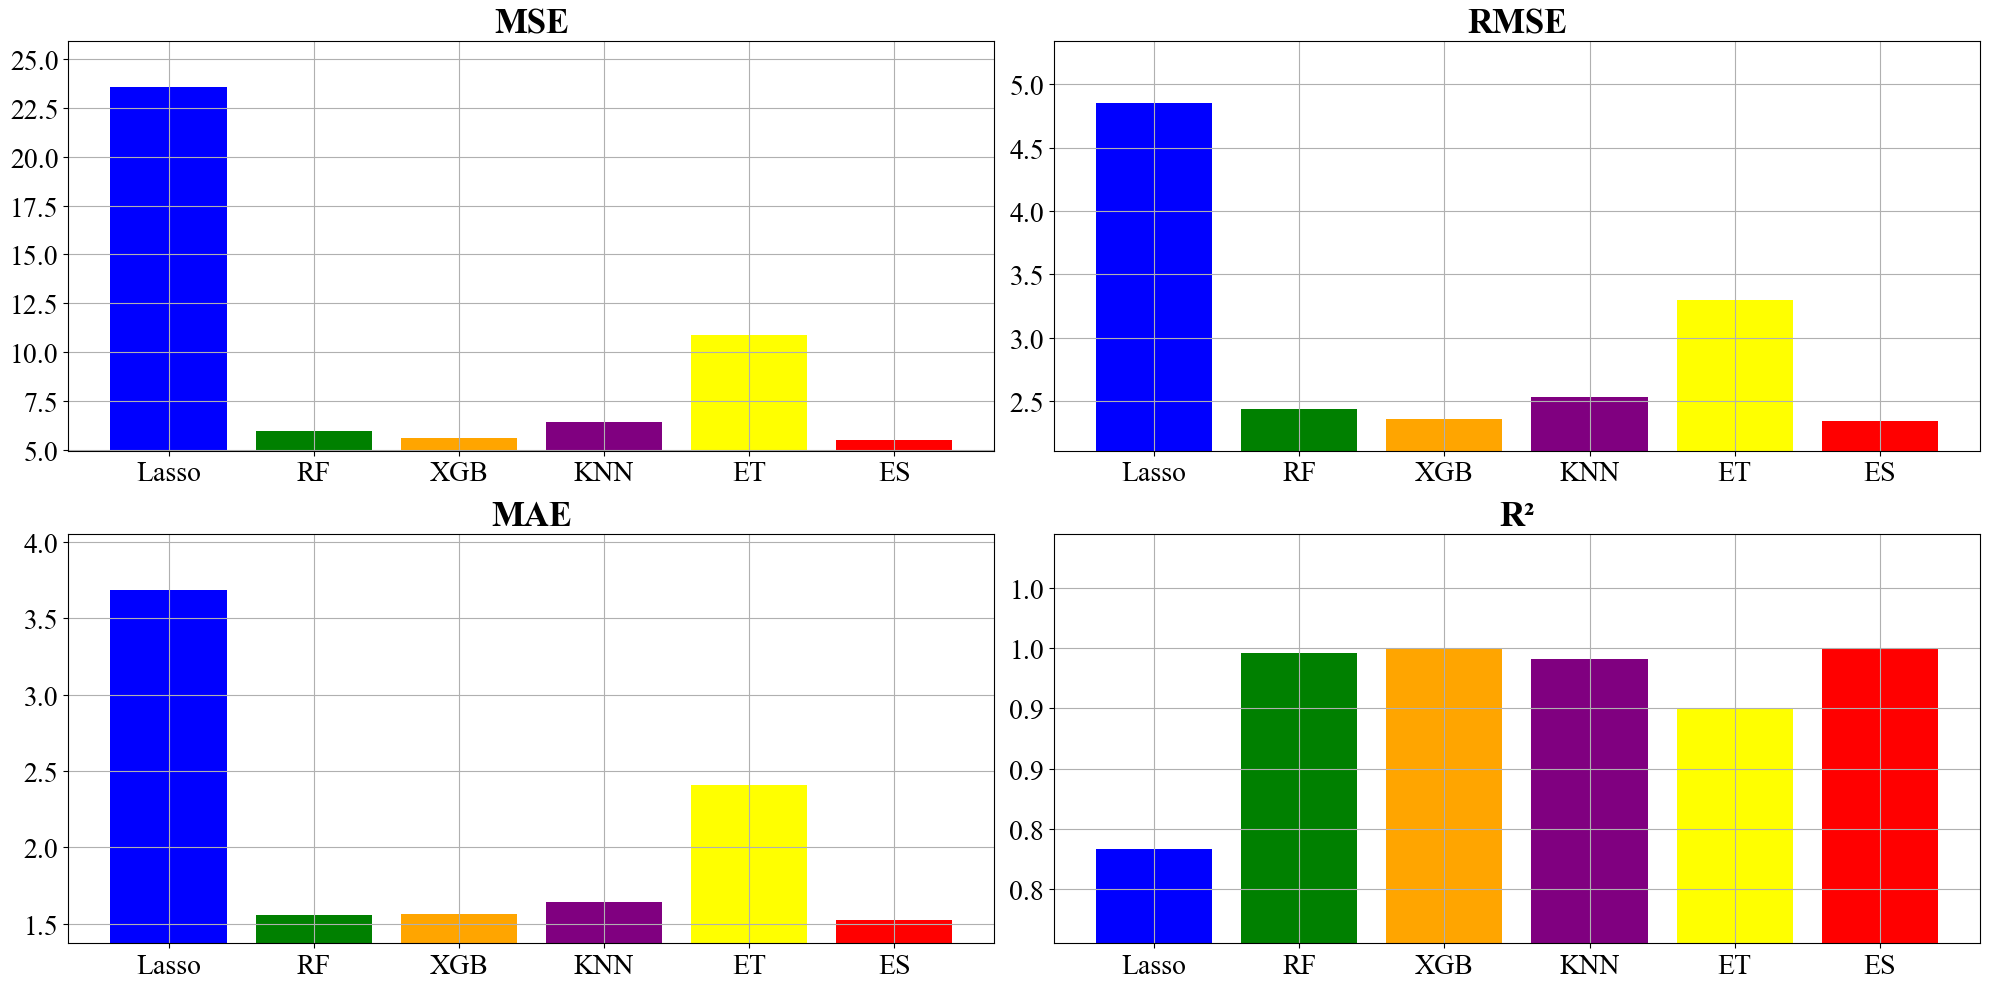

In [120]:
metrics = ['MSE', 'RMSE', 'MAE', 'R²']
models = ['Lasso', 'RF',  'XGB', 'KNN', 'ET', 'ES']
scores = {
    'Lasso': [mse_lasso_grecipe, rmse_lasso_grecipe, mae_lasso_grecipe, r2_lasso_grecipe],
    'RF': [mse_rf_grecipe, rmse_rf_grecipe, mae_rf_grecipe, r2_rf_grecipe],
    'XGB': [mse_xgb_grecipe, rmse_xgb_grecipe, mae_xgb_grecipe, r2_xgb_grecipe],
    'KNN': [mse_knn_grecipe, rmse_knn_grecipe, mae_knn_grecipe, r2_knn_grecipe], 
    'ET': [mse_ensamble_grecipe, rmse_ensamble_grecipe, mae_ensamble_grecipe, r2_ensamble_grecipe],
    'ES': [mse_ensamble_grecipe_select, rmse_ensamble_grecipe_select, mae_ensamble_grecipe_select, r2_ensamble_grecipe_select]
}

# Subplots
fig, axs = plt.subplots(2, 2, figsize=(20, 10))  # Ajustar tamaño para una mejor visualización

# Configuración del gráfico para cada métrica
for i, metric in enumerate(metrics):
    ax = axs.flat[i]  # Acceder correctamente a cada subtrama
    values = [scores[model][i] for model in models]
    ax.bar(models, values, color=['blue', 'green', 'orange', 'purple', 'yellow', 'red', 'black'])
    ax.set_title(f'{metric}', fontsize=25, fontweight='bold')
    ax.set_ylim(min(values) - 0.1 * abs(min(values)), max(values) + 0.1 * abs(max(values)))  # Ajustar según los valores
    ax.set_xticklabels(models, rotation=0, fontsize=20)
    y_ticks = ax.get_yticks()
    ax.set_yticklabels([f'{y_tick:.1f}' for y_tick in y_ticks], fontsize=20)
    ax.grid(True)

plt.tight_layout()

# Guardar la figura completa en un archivo
plt.savefig('model_performance_metrics_grecipe.png', dpi=300)

plt.show()


### Comparación de los modelos en el batch 15

In [121]:
# Cargar las predicciones
load_pred_lasso_grecipe = pd.read_csv(r'y_pred_lasso_grecipe.csv')
load_pred_rf_grecipe = pd.read_csv(r'y_pred_rf_grecipe.csv')
load_pred_xgb_grecipe = pd.read_csv(r'y_pred_xgb_grecipe.csv')
load_pred_knn_grecipe = pd.read_csv(r'y_pred_knn_grecipe.csv')
load_pred_ensamble_select_grecipe = pd.read_csv(r'y_pred_ensamble_grecipe_select.csv')

In [123]:
# se hace un reset a los índices de grecipe_test para poder concatenar 
grecipe_test_reset = grecipe_test.reset_index(drop=True)
# concatenar 
data_select_pred_grecipe = pd.concat([grecipe_test_reset, load_pred_lasso_grecipe, load_pred_rf_grecipe, 
                                     load_pred_xgb_grecipe, load_pred_knn_grecipe, load_pred_ensamble_select_grecipe], axis=1).reset_index(drop=True)

In [124]:
# Batch 15
batch_15_select = data_select_pred_grecipe[data_select_pred_grecipe['Batch'] == 15]

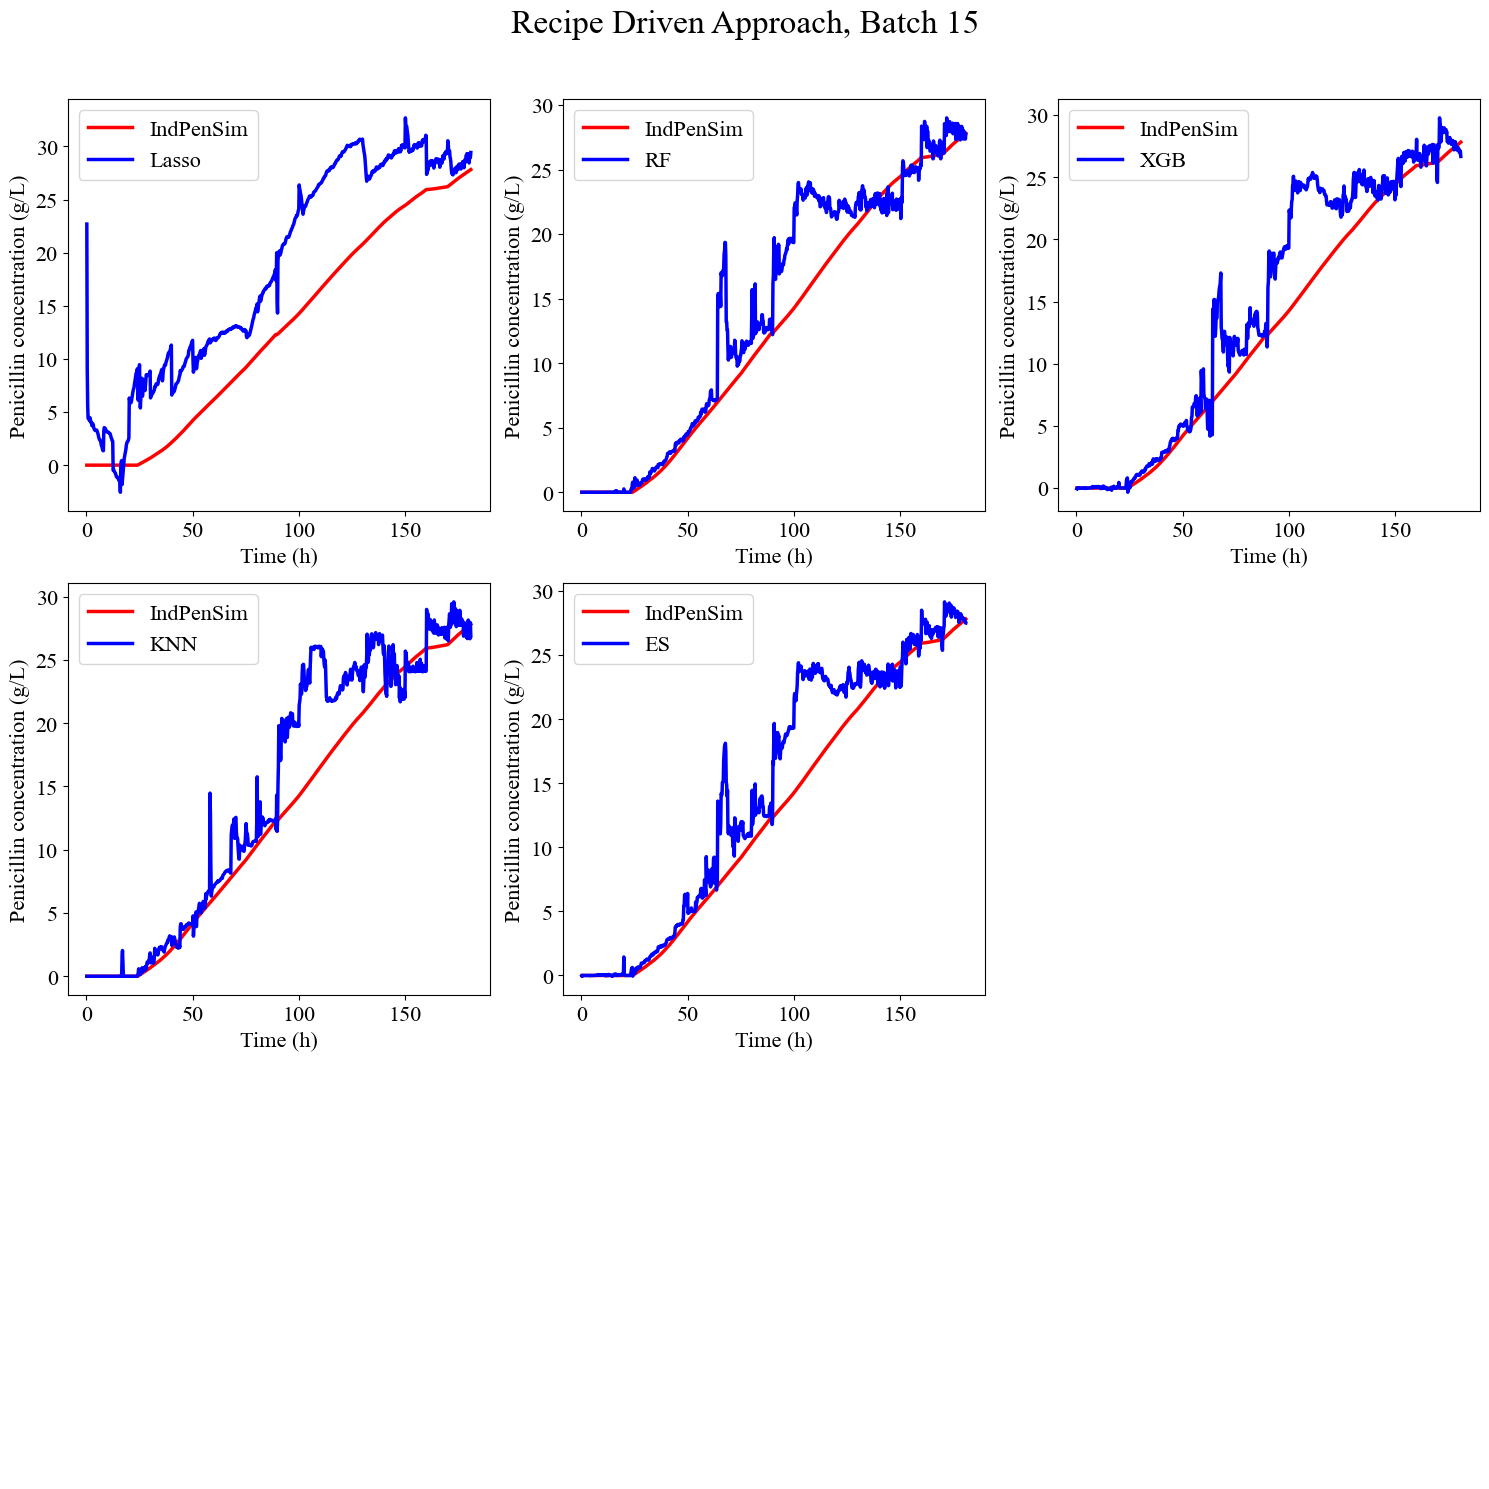

In [127]:
# Configurar matplotlib para usar Times New Roman
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']

# Predicciones
pred_columns = [
    'pred_lasso_grecipe', 'pred_rf_grecipe', 
    'pred_xgb_grecipe', 'pred_knn_grecipe', 'pred_ensamble_select_grecipe'
]

# Nuevos nombres para las columnas
column_names = {
    'pred_lasso_grecipe': 'Lasso',
    'pred_rf_grecipe': 'RF',
    'pred_xgb_grecipe': 'XGB',
    'pred_knn_grecipe': 'KNN',
    'pred_ensamble_select_grecipe': 'ES'
}

# Series de pandas a arrays de NumPy
x = batch_15_select['Time (h)'].to_numpy()
y1 = batch_15_select['Penicillin concentration(P:g/L)'].to_numpy()

# Subplots 3x3
fig, axs = plt.subplots(3, 3, figsize=(15, 15))

# Título
fig.suptitle("Recipe Driven Approach, Batch 15", fontsize=24)

# Predicciones y las posiciones de los subplots
for i, ax in enumerate(axs.flatten()):
    if i < len(pred_columns):
        y2 = batch_15_select[pred_columns[i]].to_numpy()
        ax.plot(x, y1, 'r', label='IndPenSim', linewidth=2.5)
        ax.plot(x, y2, 'b', label=column_names[pred_columns[i]], linewidth=2.5)
        #ax.set_title(column_names[pred_columns[i]], fontsize=18)
        ax.set_xlabel("Time (h)", fontsize=16)
        ax.set_ylabel('Penicillin concentration (g/L)', fontsize=16)
        ax.tick_params(axis='both', which='major', labelsize=16)
        ax.legend(fontsize=16)
    else:
        # Si hay más subplots que columnas, ocultar los subplots adicionales
        ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Ajustar el espaciado y dejar espacio para el título principal
fig.subplots_adjust(bottom=0.0001, top=0.92)  # Ajustar el espacio en la parte inferior y superior

# Guardar la figura completa en un archivo
plt.savefig('model_performance_grecipe_batch_15.png', dpi=300, bbox_inches='tight')

plt.show()


#### Graficamos los modelos seleccionados y el ensamble

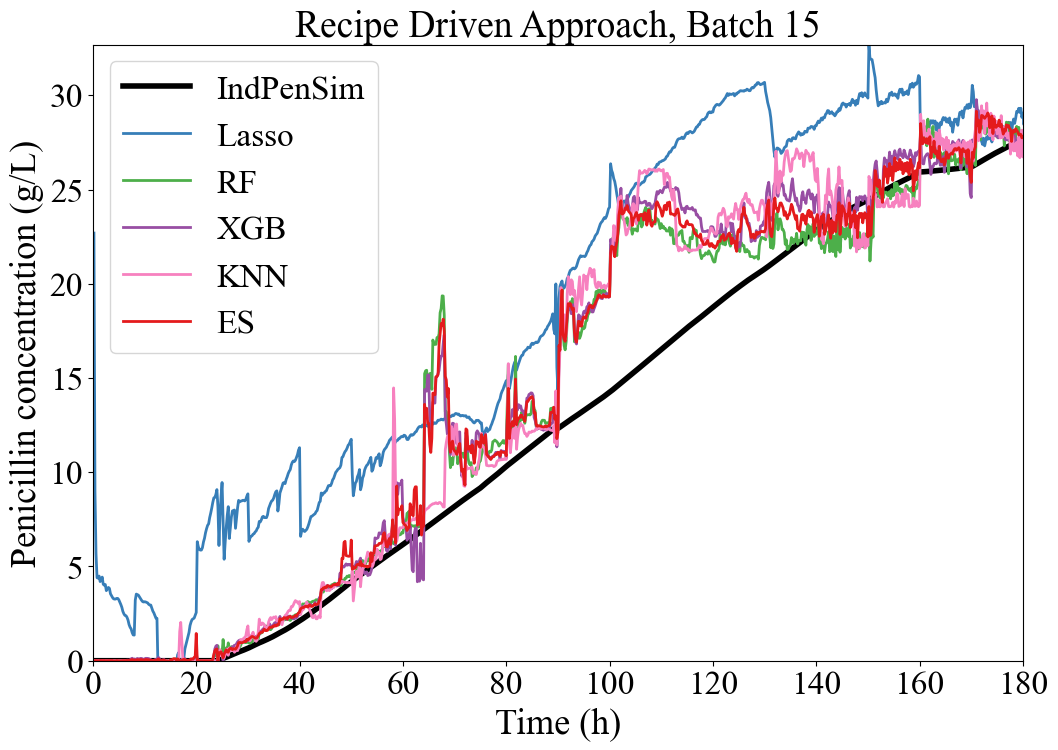

In [129]:
# Predicciones
pred_columns = ['pred_lasso_grecipe',
    'pred_rf_grecipe', 'pred_xgb_grecipe', 'pred_knn_grecipe', 'pred_ensamble_select_grecipe'
]

# Colores
colors = {
    'IndPenSim': 'black',
    'pred_lasso_grecipe': '#377eb8',  # Ajustado a un azul más contrastante
    'pred_rf_grecipe': '#4daf4a',     # Ajustado a un verde más claro
    'pred_xgb_grecipe': '#984ea3',    # Púrpura más oscuro
    'pred_knn_grecipe': '#f781bf',    # Rojo más brillante
    'pred_ensamble_select_grecipe': '#e41a1c' # Rosa más claro e41a1c
}

# Labels
labels = {
    'IndPenSim': 'IndPenSim',
    'pred_lasso_grecipe': 'Lasso',
    'pred_rf_grecipe': 'RF',
    'pred_xgb_grecipe': 'XGB',
    'pred_knn_grecipe': 'KNN',
    'pred_ensamble_select_grecipe': 'ES'
}

# Series de pandas a arrays de NumPy
x = batch_15_select['Time (h)'].to_numpy()
y1 = batch_15_select['Penicillin concentration(P:g/L)'].to_numpy()

# Figura
plt.figure(figsize=(12, 8))

# Graficar IndPenSim
plt.plot(x, y1, label=labels['IndPenSim'], linewidth=4, color=colors['IndPenSim'])

# Iterar a través de las columnas de predicciones y graficarlas con diferentes colores y nombres
for pred_col in pred_columns:
    y2 = batch_15_select[pred_col].to_numpy()
    plt.plot(x, y2, label=labels[pred_col], linewidth=2, color=colors[pred_col])

# Límites del eje x e y
plt.xlim(0, 180)
plt.ylim(0, max(y1.max(), *[batch_15_select[col].max() for col in pred_columns]))

# Leyenda
plt.legend(fontsize=24)

# Título y etiquetas de los ejes
plt.title("Recipe Driven Approach, Batch 15", fontsize=27)
plt.xlabel("Time (h)", fontsize=26)
plt.ylabel('Penicillin concentration (g/L)', fontsize=26)

# Ticks de los ejes
plt.tick_params(axis='both', which='major', labelsize=24)

# Guardar la figura completa en un archivo
plt.savefig('model_performance_grecipe_batch_15_join.png', dpi=300, bbox_inches='tight')

# Mostrar la gráfica
plt.show()

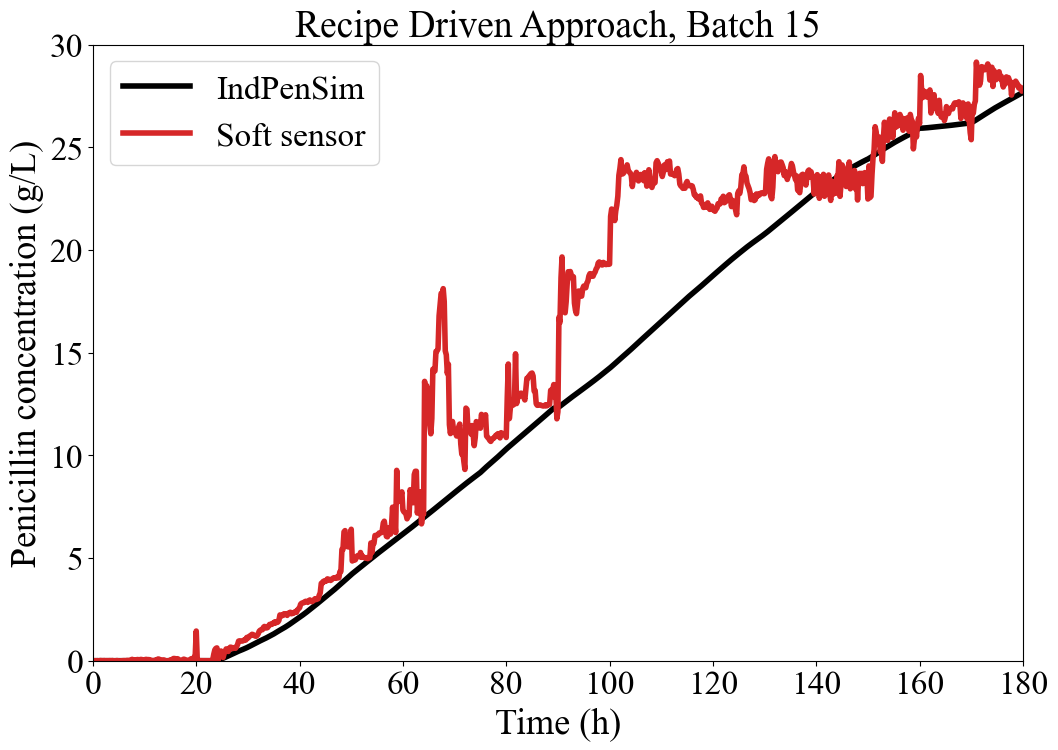

In [130]:
# Colores
colors = {
    'IndPenSim': 'black',
    'pred_ensamble_select_grecipe': '#d62728'
}

# Labels
labels = {
    'IndPenSim': 'IndPenSim',
    'Soft sensor': 'Soft sensor'
}

# Series de pandas a arrays de NumPy
x = batch_15_select['Time (h)'].to_numpy()
y1 = batch_15_select['Penicillin concentration(P:g/L)'].to_numpy()
y2 = batch_15_select['pred_ensamble_select_grecipe'].to_numpy()

# Figura
plt.figure(figsize=(12, 8))

# Graficar IndPenSim
plt.plot(x, y1, label=labels['IndPenSim'], linewidth=4, color=colors['IndPenSim'])
plt.plot(x, y2, label=labels['Soft sensor'], linewidth=4, color=colors['pred_ensamble_select_grecipe'])

# Límites del eje x e y
plt.xlim(0, 180)
plt.ylim(0, 30)

# Leyenda
plt.legend(fontsize=24)

# Título y etiquetas de los ejes
plt.title("Recipe Driven Approach, Batch 15", fontsize=27)
plt.xlabel("Time (h)", fontsize=26)
plt.ylabel('Penicillin concentration (g/L)', fontsize=26)

# Ticks de los ejes
plt.tick_params(axis='both', which='major', labelsize=24)

# Guardar la figura completa en un archivo
plt.savefig('soft_sensor_batch_15_grecipe.png', dpi=300, bbox_inches='tight')

# Mostrar la gráfica
plt.show()